# Structural EDA
Goals 
- number of rows and columns
- column data types - numerical, categorical, mixed
- PK and FK
- table granularity 
- timestamp columns
- missing value overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### accounts

**conclusions**

- 500 rows, 10 columns
- categorical - referral_source, country, industry, plan_tier, is_trial, churn_flag
- numerical - seats
- mixed - account_id, account_name
- timestamp column - signup_date
- no missing values
- single customer per row
- PK - account_id, NO FK

In [2]:
accounts = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_accounts.csv")
accounts.sample(5)

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
448,A-297a2d,Company_448,HealthTech,UK,2023-05-05,event,Pro,27,False,False
381,A-0a62f5,Company_381,FinTech,UK,2024-09-11,partner,Pro,16,False,False
499,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False
473,A-4a4c2d,Company_473,DevTools,US,2023-05-02,event,Enterprise,54,False,False
454,A-0be015,Company_454,FinTech,US,2024-10-15,event,Pro,19,False,False


In [9]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


In [ ]:
# checking for duplicate values
accounts.shape[0] == accounts['account_id'].nunique() # indicates no duplicates

True

In [ ]:
# checking for null values
accounts.isnull().sum()

account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

In [23]:
accounts['seats'].nunique()

73

In [75]:
# checking all the unique plan tiers
accounts['plan_tier'].unique()

array(['Basic', 'Enterprise', 'Pro'], dtype=object)

### churn_events

**conclusions**

- rows 600, columns 9
- categorical - reason_code, preceding_upgrade_flag, preceding_dewngrade_flag, is_reactivation, feedback_text
- numerical - refund_amount_usd
- mixed - churn_event_id, account_id
- timestamp column - churn_date
- granularity - single churn per row
- feedback_text has null values 600 - 452 = 148 null values, filling needed
- PK Churn_event_id, FK - account_id
- insights
  - doesn't account for reactivations
  - only records churn events


In [3]:
churn_events = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_churn_events.csv")
churn_events.head(5)

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [69]:
churn_events[churn_events['account_id'] == 'A-956988']

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
4,C-92f889,A-956988,2024-12-30,unknown,0.0,False,True,True,too expensive
145,C-c6998d,A-956988,2024-12-08,budget,0.0,True,False,False,missing features


In [26]:
churn_events['feedback_text'].unique()

array(['switched to competitor', nan, 'missing features', 'too expensive'],
      dtype=object)

In [27]:
churn_events['reason_code'].unique()

array(['pricing', 'support', 'budget', 'unknown', 'features',
       'competitor'], dtype=object)

In [19]:
churn_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


In [31]:
churn_events['account_id'].nunique()

352

In [55]:
churn_events['account_id'].nunique

<bound method IndexOpsMixin.nunique of 0      A-c37cab
1      A-37f969
2      A-b07346
3      A-1e50e0
4      A-956988
         ...   
595    A-702032
596    A-dbc825
597    A-0a282f
598    A-e5d6ab
599    A-1f559b
Name: account_id, Length: 600, dtype: object>

### subscriptions

**conclusions**

- rows - 5000, cols - 14
- cateorical - plan_tier, is_trial, upgrade_flag, down_grade_flag, auto_renew_flag, billing_frequency, churn_flag
- numerical - seats, mrr_amount, arr_amount
- mixed - subscription_id, account_id
- timestamp cols - start_date, end_date
- end_date has missing values 
- granularity - subcription level events
- PK - subscription_id, FK - account_id
- insights - New records appear due to
  - plan changes
  - reactivations
  - seats change
  - billing frequency
  - trial starts

In [4]:
subs = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_subscriptions.csv")
subs.sample(5)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
1730,S-5a4fb5,A-462d45,2024-02-13,NaN,Pro,13,637,7644,False,True,False,False,annual,True
3850,S-6d10f7,A-7641d3,2024-11-17,NaN,Pro,16,784,9408,False,False,False,False,monthly,True
2455,S-dc6a2a,A-309e54,2024-12-21,NaN,Pro,15,0,0,True,False,False,False,monthly,True
1927,S-8bac4e,A-558c72,2023-12-17,NaN,Pro,12,588,7056,False,False,False,False,monthly,True
3339,S-3476e2,A-cb6cc6,2024-09-07,NaN,Basic,13,247,2964,False,True,False,False,monthly,False


In [29]:
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


In [53]:
subs['account_id'].duplicated().sum()

np.int64(4500)

In [73]:
accounts[accounts['account_id'] == 'A-b9f5b1']

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
494,A-b9f5b1,Company_494,Cybersecurity,US,2023-01-24,other,Pro,15,True,False


In [71]:
churn_events[churn_events['account_id'] == 'A-b9f5b1']

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
13,C-875dc5,A-b9f5b1,2023-07-21,features,0.0,False,False,False,switched to competitor


In [72]:
subs[subs["account_id"] == "A-b9f5b1"].sort_values("start_date")

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
4339,S-2ad954,A-b9f5b1,2023-03-12,NaN,Enterprise,42,0,0,True,False,False,False,monthly,True
2587,S-869bba,A-b9f5b1,2023-10-31,NaN,Enterprise,15,0,0,True,False,False,False,annual,False
999,S-b22602,A-b9f5b1,2024-05-04,2024-09-29,Enterprise,39,0,0,True,False,False,True,annual,True
3338,S-12f05a,A-b9f5b1,2024-06-23,NaN,Basic,15,285,3420,False,False,False,False,annual,False
367,S-3a28a1,A-b9f5b1,2024-07-25,NaN,Enterprise,15,2985,35820,False,False,False,False,annual,True
553,S-65071f,A-b9f5b1,2024-08-11,NaN,Basic,43,817,9804,False,False,False,False,monthly,True
2942,S-e78c09,A-b9f5b1,2024-10-15,NaN,Enterprise,15,2985,35820,False,False,False,False,annual,True


data integrity issue

- upgrade, downgrade and churn flags are inconsistent, manipulation is needed

### support_tickets

**conclusions**

- rows - 2000, cols - 9
- cateogorical - priority, satisfaction_score, escalation_flag
- numerical - resolution_time_hours, first_response_time_minutes
- mixed - ticket_id, account_id
- timestamp cols - submitted_at, closed_at
- granularity - ticket-level - a row per ticket
- missing values - satisfaction_score has missing values
- PK - ticket_id, FK - account_id

In [5]:
sup_ticks = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_support_tickets.csv")
sup_ticks.sample(5)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
811,T-5dbf5b,A-7cfe77,2023-03-15,2023-03-16 14:00:00,38.0,high,154,3.0,False
1352,T-6a8698,A-117171,2023-09-14,2023-09-14 13:00:00,13.0,medium,59,3.0,False
738,T-bf6b9b,A-35083d,2023-10-02,2023-10-04 04:00:00,52.0,high,87,5.0,False
1335,T-133e5c,A-17939a,2023-08-16,2023-08-18 23:00:00,71.0,urgent,85,4.0,False
425,T-7c37e5,A-8b0451,2024-12-10,2024-12-11 23:00:00,47.0,urgent,104,NaN,False


In [56]:
sup_ticks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 127.1+ KB


In [57]:
sup_ticks['satisfaction_score'].unique()

array([nan,  4.,  5.,  3.])

### feature_usage

**conclusion**

- rows - 25000, cols - 8
- cateogrical - feature_name, is_beta_feature
- numerical - usage_count, error_count
- timestamp cols - usage_date
- mixed - subscription_id, usage_id
- granularity - feature-level - one row per feature
- PK - usage_id, FK - subscription_id
- No missing values

In [6]:
feat_usage = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_feature_usage.csv")
feat_usage.sample(5)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
22817,U-cb7f92,S-731ee3,2024-04-30,feature_10,13,5018,3,False
16730,U-f052fc,S-13ca37,2024-04-28,feature_5,7,1505,0,False
12090,U-9328a5,S-04ec2f,2023-09-22,feature_2,11,6545,1,True
2897,U-ab5c44,S-7fb77e,2024-04-06,feature_4,3,393,0,False
10713,U-45c66a,S-dfd629,2024-08-25,feature_23,8,2768,0,False


In [59]:
feat_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 1.4+ MB


# Table-Level EDA

In [2]:
accounts = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_accounts.csv")
churn_events = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_churn_events.csv")
subs = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_subscriptions.csv")
sup_ticks = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_support_tickets.csv")
feat_usage = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_feature_usage.csv")

## accounts

In [8]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


### seats
**conclusions**

- has few outliers
- No missing values
- Data is highly right skewed
    - log transformation needed OR
    - a new category account_size - small/medium/large could be made 

In [86]:
accounts['seats'].describe()

count    500.000000
mean      20.560000
std       21.044718
min        1.000000
25%        5.000000
50%       15.000000
75%       28.000000
max      163.000000
Name: seats, dtype: float64

In [116]:
accounts['seats'].value_counts()

seats
1      37
3      27
5      26
9      22
4      19
       ..
42      1
105     1
117     1
54      1
148     1
Name: count, Length: 73, dtype: int64

<Axes: ylabel='Density'>

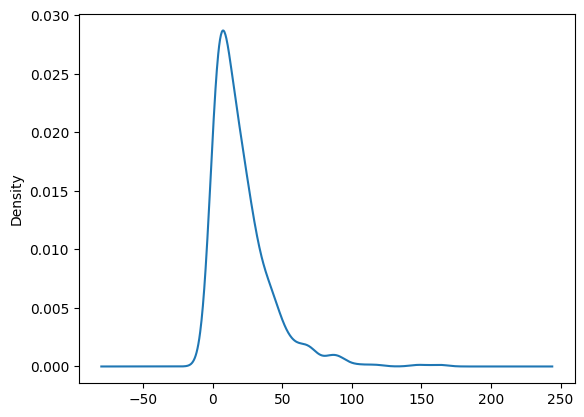

In [93]:
accounts['seats'].plot(kind='kde')

<Axes: >

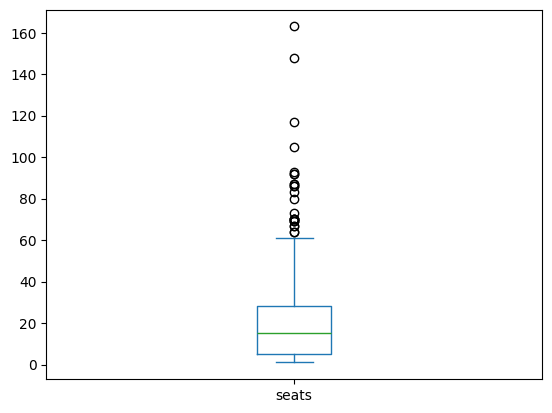

In [91]:
accounts['seats'].plot(kind='box')

<Axes: xlabel='plan_tier', ylabel='seats'>

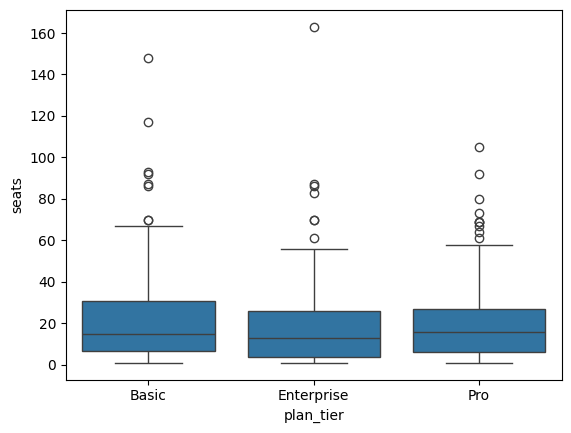

In [27]:
sns.boxplot(x='plan_tier', y='seats', data=accounts)

<Axes: xlabel='churn_flag', ylabel='seats'>

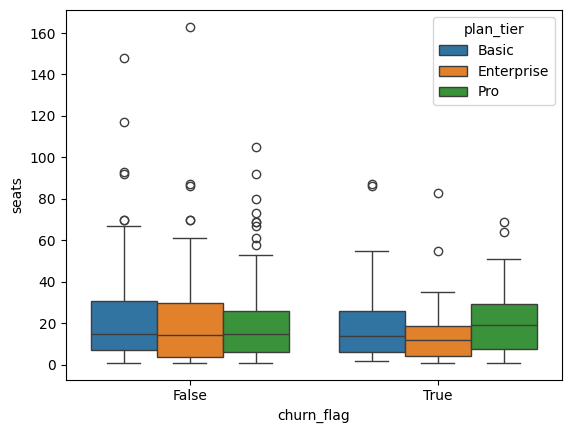

In [29]:
sns.boxplot(x='churn_flag', y='seats', data=accounts, hue='plan_tier')

- large organizations rarely chrun suggesting higher switching costs 
- churned account tend to have smaller seat counts

In [92]:
accounts['seats'].skew()

np.float64(2.325966766477256)

### industry 
**conclusions**

- well balanced accross all the industries, unlikely to bias the model heavily
- No missing values
- DevTools show high churn ~30%, and EdTech and Cybersecurity show low churn ~16%

In [ ]:
accounts['industry'].value_counts()

industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79
Name: count, dtype: int64

<Axes: xlabel='industry'>

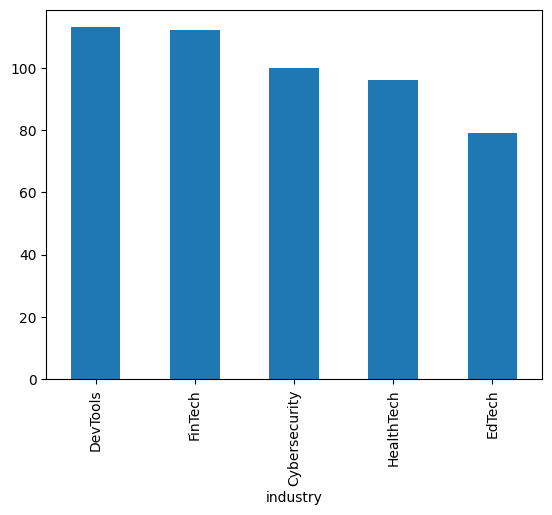

In [96]:
accounts['industry'].value_counts().plot(kind='bar')

In [ ]:
accounts['industry'].isnull().sum() # no missing values

np.int64(0)

In [15]:
# bivariate analysis
pd.crosstab(accounts['industry'], accounts['churn_flag'], normalize='index')

churn_flag,False,True
industry,,
Cybersecurity,0.840000,0.160000
DevTools,0.690265,0.309735
EdTech,0.835443,0.164557
FinTech,0.776786,0.223214
HealthTech,0.781250,0.218750


<Axes: xlabel='industry'>

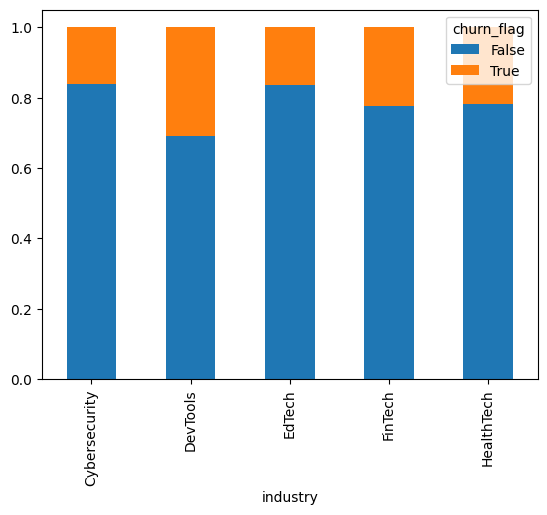

In [14]:
pd.crosstab(accounts['industry'], accounts['churn_flag'], normalize='index').plot(kind='bar', stacked=True)

### country
**conclusions**

- No missing values
- most users reside in USA
- DE(germany) has highest churn rate ~32%, US - ~23%, AU has lowest churn rate ~12.5%, else are between ~23< and > ~12%

In [98]:
accounts['country'].value_counts()

country
US    291
UK     58
IN     49
AU     32
DE     25
CA     23
FR     22
Name: count, dtype: int64

<Axes: xlabel='country'>

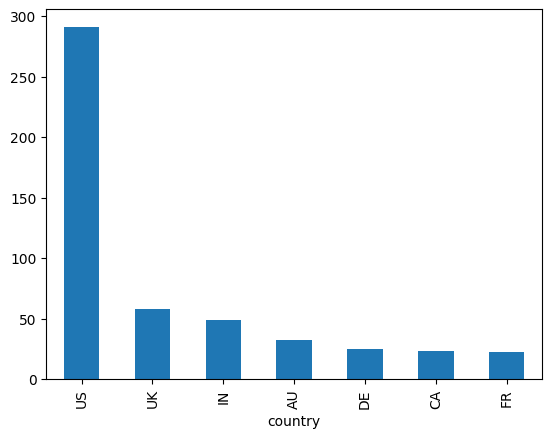

In [99]:
accounts['country'].value_counts().plot(kind='bar')

In [101]:
accounts['country'].isnull().sum() # no missing values

np.int64(0)

In [18]:
# bivariate analysis
pd.crosstab(accounts['country'], accounts['churn_flag'], normalize='index')*100

churn_flag,False,True
country,,
AU,87.500000,12.500000
CA,82.608696,17.391304
DE,68.000000,32.000000
FR,77.272727,22.727273
IN,79.591837,20.408163
UK,81.034483,18.965517
US,76.632302,23.367698


### referral source 
**conclusions**

- No missing values
- distribution is even accross all referral sources
- 'event' referral_sources with highest churn rate - ~30%
- followed by 'ads' and 'other' with ~24%
- else >~18%

In [102]:
accounts['referral_source'].value_counts()

referral_source
organic    114
other      103
ads         98
event       96
partner     89
Name: count, dtype: int64

<Axes: xlabel='referral_source'>

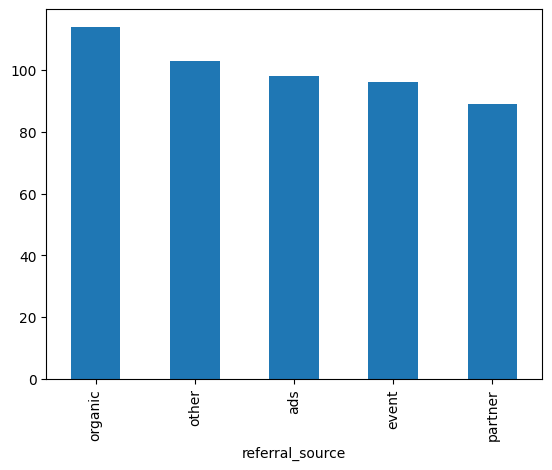

In [103]:
accounts['referral_source'].value_counts().plot(kind='bar')

In [104]:
accounts['referral_source'].isnull().sum() # no missing values

np.int64(0)

In [19]:
# bivairate analysis
pd.crosstab(accounts['referral_source'], accounts['churn_flag'], normalize='index')*100

churn_flag,False,True
referral_source,,
ads,76.530612,23.469388
event,69.791667,30.208333
organic,82.456140,17.543860
other,75.728155,24.271845
partner,85.393258,14.606742


### plan tier  
**conclusions**

- No missing values
- distribution is almost even accross all the types of sources -  Pro > Basic > Enterprise
- churn rate is same accross all the plan tier - ~22%
- On its own it may not strongly predict churn, but it could still interact with other variables such as seats or usage.
  - plan tier + seats
  - plan tier + usage
  - plan tier + tenure


In [105]:
accounts['plan_tier'].value_counts()

plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64

<Axes: xlabel='plan_tier'>

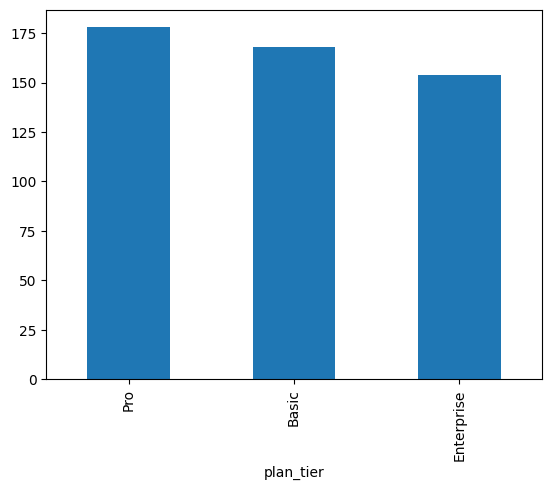

In [106]:
accounts['plan_tier'].value_counts().plot(kind='bar')

In [107]:
accounts['plan_tier'].isnull().sum()

np.int64(0)

In [21]:
# bivariate analysis
pd.crosstab(accounts['plan_tier'], accounts['churn_flag'], normalize='index')*100

churn_flag,False,True
plan_tier,,
Basic,77.976190,22.023810
Enterprise,77.922078,22.077922
Pro,78.089888,21.910112


### is_trial 
**conclusions**

- No missing values
- 80% users have paid plans
- churn rate - ~25% (trial users) > ~21% (paid users)

In [ ]:
accounts['is_trial'].value_counts()

is_trial
False    403
True      97
Name: count, dtype: int64

<Axes: xlabel='is_trial'>

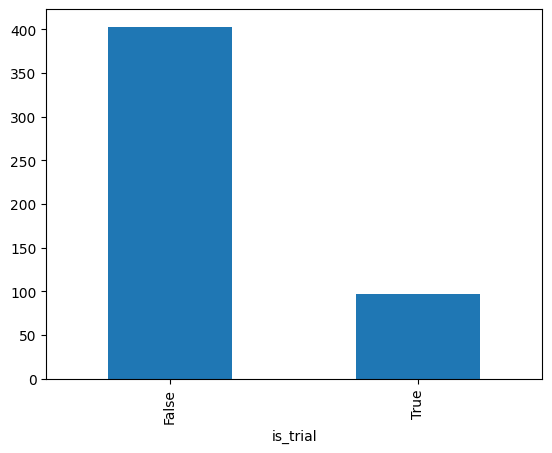

In [109]:
accounts['is_trial'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

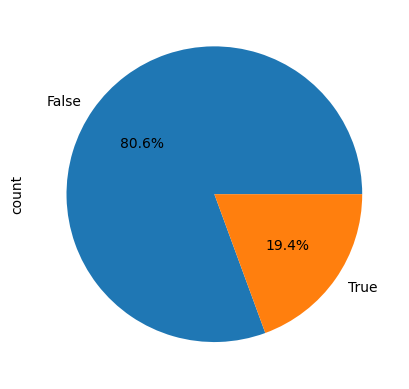

In [110]:
accounts['is_trial'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [111]:
accounts['is_trial'].isnull().sum()

np.int64(0)

In [22]:
# bivariate analysis
pd.crosstab(accounts['is_trial'], accounts['churn_flag'], normalize='index')

churn_flag,False,True
is_trial,,
False,0.789082,0.210918
True,0.742268,0.257732


### churn_flag
**conclusions**

- No missing values
- 22% overall churners accross dataset period

In [112]:
# churn rate - how imbalaned is the dataset?
accounts['churn_flag'].value_counts()

churn_flag
False    390
True     110
Name: count, dtype: int64

In [113]:
# lifetime churn rate across the dataset period
churn_rate = accounts['churn_flag'].value_counts().iloc[1] / accounts.shape[0] * 100
print(churn_rate)

22.0


In [33]:
# oldest and the newest account
print(f"oldest account: {accounts['signup_date'].min()}")
print(f"newest account: {accounts['signup_date'].max()}")

oldest account: 2023-01-02
newest account: 2024-12-31


### Accounts Table Summary

Key potential predictors:
- country
- referral_source
- is_trial
- seats
- industry

Weak standalone predictor:
- plan_tier (similar churn rates across tiers) - need coupling with other predictors to make decisions

Feature engineering ideas:
- log(seats)
- account_size bucket

## subscriptions

In [8]:
subs = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_subscriptions.csv")

In [9]:
subs.sample(5)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
858,S-02be35,A-e08cd3,2024-10-01,2024-12-21,Pro,67,3283,39396,False,False,False,True,monthly,True
3388,S-0eff34,A-b2225d,2024-08-04,NaN,Pro,47,2303,27636,False,False,False,False,monthly,False
1302,S-f869a0,A-726cfa,2024-02-29,NaN,Basic,24,456,5472,False,True,False,False,monthly,True
1203,S-25ff39,A-798a3f,2024-03-24,NaN,Basic,42,798,9576,False,False,False,False,annual,True
4407,S-c92099,A-7f4db3,2024-12-08,2024-12-14,Enterprise,24,4776,57312,False,False,False,True,annual,True


In [18]:
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


### raw table analysis

In [62]:
# subscription size of accounts over dataset period
subs.groupby('account_id').size().describe()

count    500.0000
mean      10.0000
std        3.2713
min        2.0000
25%        7.0000
50%       10.0000
75%       12.0000
max       19.0000
dtype: float64

#### timestamp columns

conclusions 

- 4514 active subcriptions are present combining all accounts, and 486 subscriptions have ended.
- per account plans lie between 7-11
- distribution of duration days among completed subs is strong positive skewed, most durations days (~75%) lie btw 0-120 days - this stats is not valid since later we found out in the feature_usage table that the subs that have shown to be ended are actually active even after the end_date.

In [8]:
# analysing active plans
active_plans = subs[subs['end_date'].isna()].shape[0]
active_plans

4514

In [142]:
# analysing active plans per accounts
subs.groupby('account_id').apply(lambda x: (x['end_date'].isna()).sum())
# subs.groupby('account_id').apply(lambda x: (x['start_date'].notna() & x['end_date'].isna()).sum()).describe()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_61652\2718628300.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subs.groupby('account_id').apply(lambda x: (x['end_date'].isna()).sum())


account_id
A-00bed1    10
A-00cac8     9
A-0158bb     6
A-016043    10
A-019782     8
            ..
A-fe79a5     8
A-ff3c73     8
A-ff79f2     7
A-ffc04f    13
A-ffdfd5     9
Length: 500, dtype: int64

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_61652\1218393257.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subs.groupby('account_id').apply(lambda x: (x['start_date'].notna() & x['end_date'].isna()).sum()).plot(kind='box')


<Axes: >

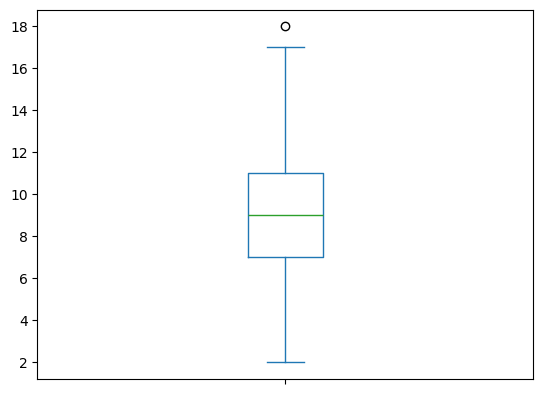

In [119]:
subs.groupby('account_id').apply(lambda x: (x['start_date'].notna() & x['end_date'].isna()).sum()).plot(kind='box')

calulating subscription duration among complete plans i.e. plans that have ended

In [66]:
import datetime as dt

In [4]:
end_subs = subs[subs['end_date'].notna()]
end_subs.head(3)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
16,S-13939b,A-86902e,2023-07-21,2024-08-03,Pro,34,0,0,True,False,False,True,monthly,True


In [5]:
end_subs['duration_days'] = (pd.to_datetime(end_subs['end_date']) - pd.to_datetime(end_subs['start_date'])).dt.days
end_subs.head(3)

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_42696\4048040174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  end_subs['duration_days'] = (pd.to_datetime(end_subs['end_date']) - pd.to_datetime(end_subs['start_date'])).dt.days


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,duration_days
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,111
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,20
16,S-13939b,A-86902e,2023-07-21,2024-08-03,Pro,34,0,0,True,False,False,True,monthly,True,379


In [69]:
end_subs['duration_days'].describe()

count    486.000000
mean      88.055556
std      110.728176
min        0.000000
25%       11.000000
50%       42.000000
75%      120.750000
max      624.000000
Name: duration_days, dtype: float64

In [70]:
end_subs['duration_days'].min()

np.int64(0)

<Axes: ylabel='Frequency'>

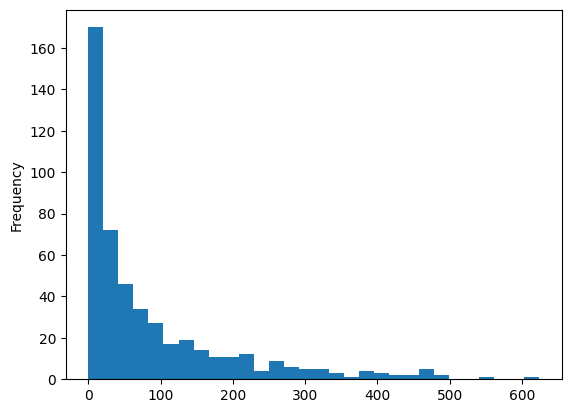

In [72]:
end_subs['duration_days'].plot(kind='hist', bins=30)

<Axes: >

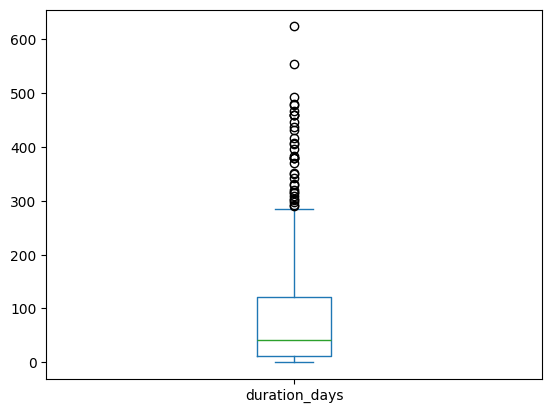

In [74]:
end_subs['duration_days'].plot(kind='box')

In [6]:
active_subs = subs[subs['end_date'].isna()]
active_subs.sample(3)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
1133,S-430691,A-4814a3,2024-11-13,NaN,Pro,87,4263,51156,False,False,False,False,monthly,True
3948,S-c9a968,A-bad8c1,2024-03-21,NaN,Basic,8,152,1824,False,False,False,False,monthly,True
147,S-5d68fb,A-5f2961,2024-12-02,NaN,Pro,49,2401,28812,False,False,False,False,annual,True


#### upgrade_flag/down_grade_flag

conclusions

- NOTE: here upgrade_flag & downgrade_flag are set only when there is an upgrade/downgrade mid-cycle (as mentioned in the readme.md) it doesn't account for any other upgrade/downgrade
- overall upgrade_flags are twice than downgrade_flags indicating upgrades are more common than downgrades
- on average an account has 1 upgrade for entire dataset period
- downgrades are rare, 75% of accounts have atmost 1 downgrades
- Hence upgrades and downgrades are preety uncommon mid-cycle
- we may conclude that upgrade/downgrade flags are not a sole churn drivers


In [80]:
# overall distribution of upgrade and downgrade events
subs['upgrade_flag'].sum(), subs['downgrade_flag'].sum(), f"total: {subs['upgrade_flag'].sum() + subs['downgrade_flag'].sum()}"

(np.int64(529), np.int64(218), 'total: 747')

In [92]:
# distribution of upgrades and downgrades per accounts
subs.groupby('account_id')['upgrade_flag'].sum().describe()

count    500.000000
mean       1.058000
std        1.081191
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: upgrade_flag, dtype: float64

In [93]:
subs.groupby('account_id')['downgrade_flag'].sum().describe()

count    500.000000
mean       0.436000
std        0.668429
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        4.000000
Name: downgrade_flag, dtype: float64

#### billing_frequency

conclusions

- monthly and annual billings are equally preferred
- monthly billing having a slight edge over annual billing

In [94]:
subs['billing_frequency'].value_counts()

billing_frequency
monthly    2539
annual     2461
Name: count, dtype: int64

#### plan_tier 

conclusions

- subscriptions/active_subs is almost evenly distributed among plan_tiers with Enterprise have slight edge over pro and basic
- seats distribution across plan_tier is also similar

In [140]:
# subs['plan_tier'].value_counts()
active_subs['plan_tier'].value_counts()

plan_tier
Enterprise    1551
Pro           1513
Basic         1450
Name: count, dtype: int64

<Axes: xlabel='plan_tier', ylabel='seats'>

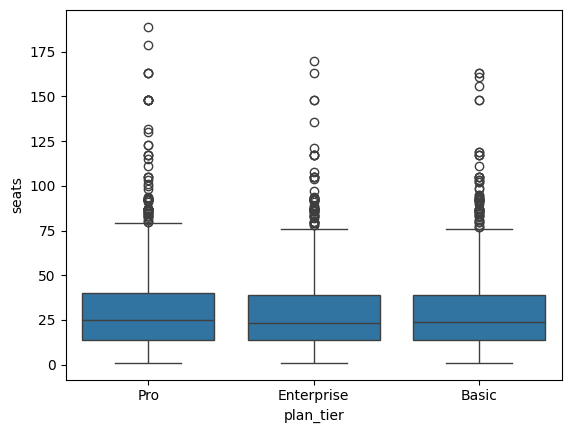

In [137]:
# check plan_tier and seats relationship among active subscriptions
sns.boxplot(x='plan_tier', y='seats', data=active_subs) 

Text(0.5, 1.0, 'Seats distribution across Plan Tiers among active subscriptions')

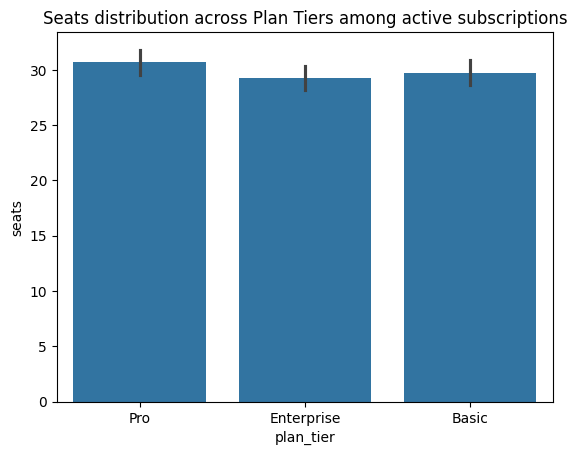

In [138]:
# almost same seats distribution across plan tiers
# let's confirm it with barplot
sns.barplot(x='plan_tier', y='seats', data=active_subs)
plt.title("Seats distribution across Plan Tiers among active subscriptions")

#### mrr_amount/arr_amount

conclusions

- enterprise >>> pro > basic is the order of contribution of plan tiers to mrr_amount and arr_amount
- enterprise has significantly higher price per seats then pro and basic plans, this explains the significant difference between each tier contribution to arr and mrr amount


In [126]:
active_subs['mrr_amount'].describe()

count     4514.000000
mean      2250.688525
std       3364.825789
min          0.000000
25%        285.000000
50%        931.000000
75%       2786.000000
max      33830.000000
Name: mrr_amount, dtype: float64

<Axes: >

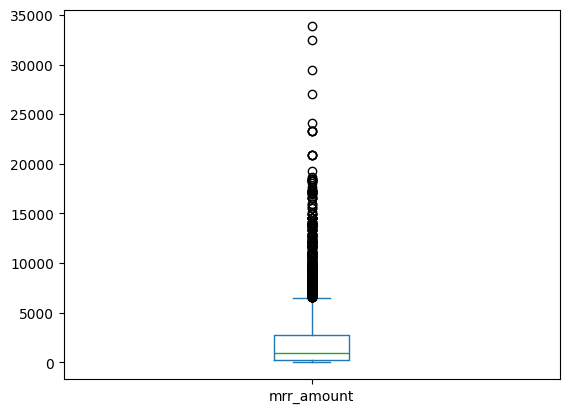

In [127]:
# subs['mrr_amount'].plot(kind='hist', bins=10)
active_subs['mrr_amount'].plot(kind='box')

In [128]:
# arr_amount
active_subs['arr_amount'].describe()

count      4514.000000
mean      27008.262295
std       40377.909465
min           0.000000
25%        3420.000000
50%       11172.000000
75%       33432.000000
max      405960.000000
Name: arr_amount, dtype: float64

Text(0.5, 1.0, 'MRR Amount across Plan Tiers among active subscriptions')

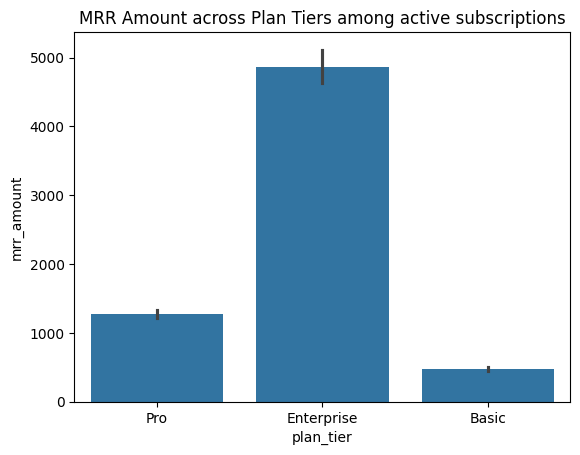

In [130]:
sns.barplot(x='plan_tier', y='mrr_amount', data=active_subs)
plt.title("MRR Amount across Plan Tiers among active subscriptions")

<Axes: xlabel='plan_tier', ylabel='mrr_amount'>

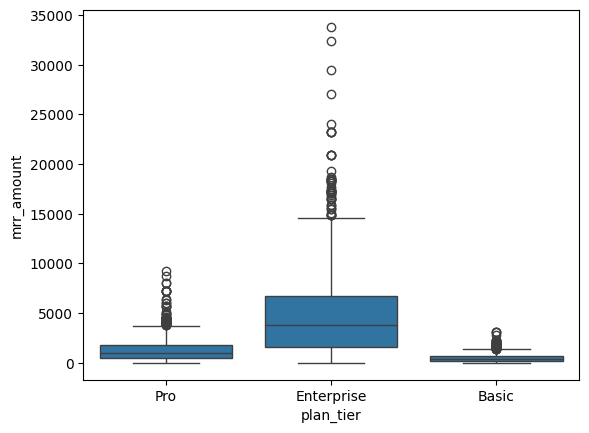

In [131]:
# mrr_amount vs plan_tier
sns.boxplot(x='plan_tier', y='mrr_amount', data=active_subs)

<Axes: ylabel='Frequency'>

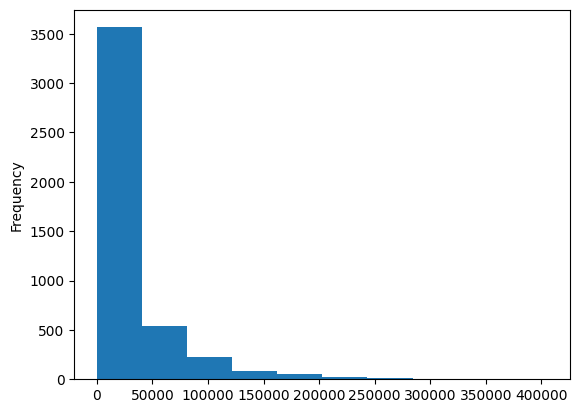

In [132]:
active_subs['arr_amount'].plot(kind='hist', bins=10)

<Axes: xlabel='plan_tier', ylabel='arr_amount'>

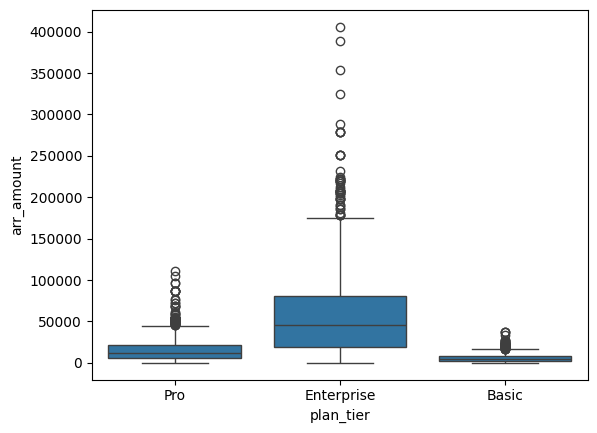

In [133]:
sns.boxplot(x='plan_tier', y='arr_amount', data=active_subs)

Text(0.5, 1.0, 'ARR Amount across Plan Tiers among active subscriptions')

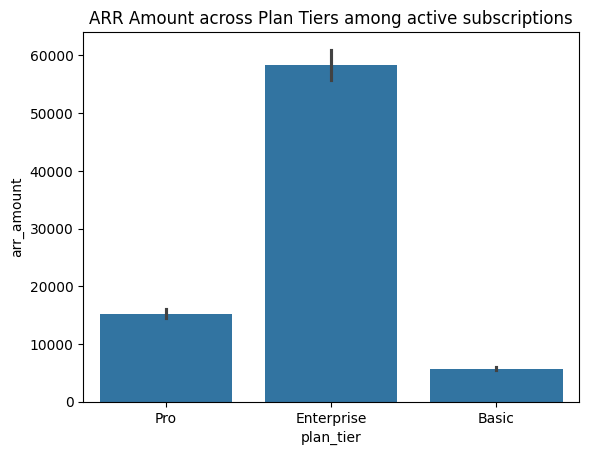

In [135]:
sns.barplot(x='plan_tier', y='arr_amount', data=active_subs)
plt.title("ARR Amount across Plan Tiers among active subscriptions")

<Axes: xlabel='plan_tier', ylabel='seats'>

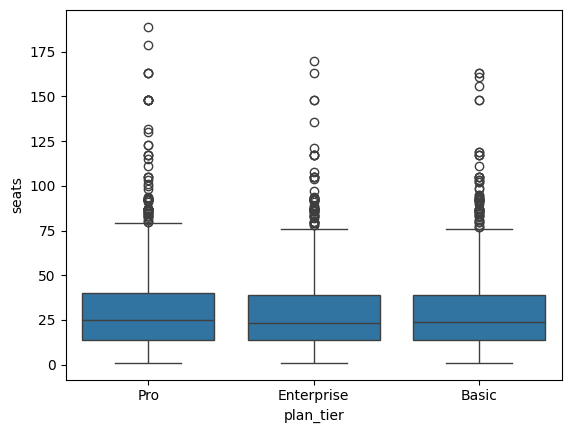

In [136]:
# let's distribute seats accross plan tiers among active subscriptions
sns.boxplot(x='plan_tier', y='seats', data=active_subs)

- we can clearly see that the enterprise's contribution to the mrr_amount is higher than any other plan_tier
- even though the active plans distribution across tiers is almost same
- infact the seats distribution across plan tiers is almost same
- what could be the reason behind enterprise's mrr_amount being so significantly high?

In [139]:
active_subs.groupby('plan_tier')['mrr_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
plan_tier,,,,,,,,
Basic,1450.0,474.423448,440.315619,0.0,156.75,380.0,646.0,3097.0
Enterprise,1551.0,4865.813024,4539.238179,0.0,1592.00,3781.0,6766.0,33830.0
Pro,1513.0,1272.186385,1219.216485,0.0,441.00,1029.0,1764.0,9261.0


- assumption - may be enterprises are paying much higher per seats than pro/basic plan accounts

In [145]:
# average per-subscription per-seat mrr across plan_tiers amont active subscriptions
results = active_subs.groupby('plan_tier').apply(lambda x: (x['mrr_amount'] / x['seats']).mean())
results

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_61652\3886541678.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = active_subs.groupby('plan_tier').apply(lambda x: (x['mrr_amount'] / x['seats']).mean())


plan_tier
Basic          16.091034
Enterprise    167.308833
Pro            41.518837
dtype: float64

In [147]:
[((results.max() / i) - 1) * 100 for i in results]

[np.float64(939.7643059570248), np.float64(0.0), np.float64(302.9709069782284)]

- we can see that the average per-subcription per-seat is significantly higher for enterprice > pro > basic
- i.e. enterprice's average per-seat per-subscription is 9.5 times higher than basic plans, and 3 times higher than pro plans
- hence, we conclude that enterprise tiers pay more per seat than any other tier explaining the significant difference in mrr_contribution

#### is_trial

conclusions

- majority account(~75%) have 2 trial subscriptions active

In [151]:
# active_subs.groupby(['account_id', 'is_trial']).value_counts()
active_subs.groupby('account_id')['is_trial'].sum().describe()

count    500.000000
mean       1.400000
std        1.128959
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: is_trial, dtype: float64

<Axes: ylabel='Frequency'>

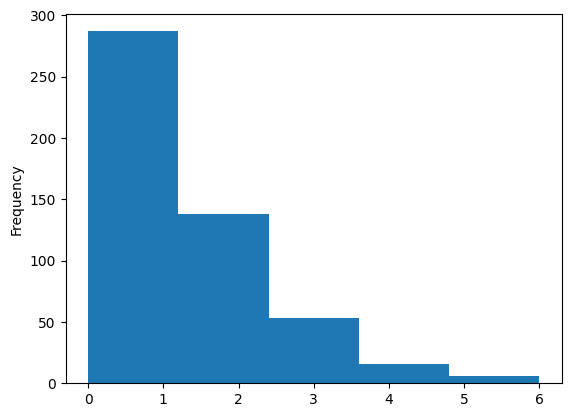

In [153]:
active_subs.groupby('account_id')['is_trial'].sum().plot(kind='hist', bins=5)

#### auto_renew_flag

conclusions 

- majority active_subs have their auto_renewal set

In [ ]:
results_auto = active_subs['auto_renew_flag'].value_counts()
results_auto

auto_renew_flag
True     3615
False     899
Name: count, dtype: int64

<Axes: xlabel='auto_renew_flag'>

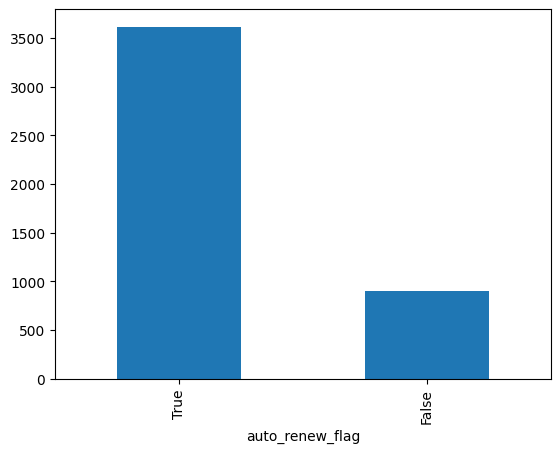

In [155]:
active_subs['auto_renew_flag'].value_counts().plot(kind='bar')

### time-aware analysis (before churn / normal behaviour)

In [10]:
subs = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_subscriptions.csv")
churn_events = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_churn_events.csv")

In [44]:
subs.sample(2)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
2966,S-d507da,A-aa9511,2023-11-01,NaN,Enterprise,23,4577,54924,False,False,False,False,annual,True
3733,S-b27c2f,A-625d0b,2024-12-24,NaN,Pro,17,833,9996,False,False,False,False,monthly,True


In [20]:
# merging to get the churn date for all the accounts
subs1 = subs.merge(churn_events[['account_id', 'churn_date']], on='account_id', how='left')

In [21]:
subs.shape, subs1.shape

((5000, 14), (7429, 15))

In [22]:
subs1.head(2)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,NaN
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True,2024-09-04


In [23]:
subs1['account_id'].nunique()

500

In [24]:
subs1[subs1['churn_date'].isnull()]['account_id'].nunique()

148

In [56]:
churn_events['account_id'].nunique()

352

In [25]:
subs1[subs1["account_id"] == "A-b9f5b1"]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date
553,S-3a28a1,A-b9f5b1,2024-07-25,NaN,Enterprise,15,2985,35820,False,False,False,False,annual,True,2023-07-21
826,S-65071f,A-b9f5b1,2024-08-11,NaN,Basic,43,817,9804,False,False,False,False,monthly,True,2023-07-21
1509,S-b22602,A-b9f5b1,2024-05-04,2024-09-29,Enterprise,39,0,0,True,False,False,True,annual,True,2023-07-21
3844,S-869bba,A-b9f5b1,2023-10-31,NaN,Enterprise,15,0,0,True,False,False,False,annual,False,2023-07-21
4360,S-e78c09,A-b9f5b1,2024-10-15,NaN,Enterprise,15,2985,35820,False,False,False,False,annual,True,2023-07-21
4964,S-12f05a,A-b9f5b1,2024-06-23,NaN,Basic,15,285,3420,False,False,False,False,annual,False,2023-07-21
6453,S-2ad954,A-b9f5b1,2023-03-12,NaN,Enterprise,42,0,0,True,False,False,False,monthly,True,2023-07-21


In [58]:
churn_events['account_id'].value_counts().describe()

count    352.000000
mean       1.704545
std        0.846095
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: count, dtype: float64

account_id "A-180abf" has total churn_events 5 i.e. this account has churned over 5 time for the dataset period

In [35]:
# let's see total number of subs of account_id "A-180abf"
subs[subs['account_id'] == 'A-180abf'].shape

(9, 14)

In [34]:
# let's see total number of subs of account_id "A-180abf" in merged dataframe
subs1[subs1['account_id'] == 'A-180abf'].shape

(45, 15)

- we can see that by normal df1.merge(df2) we got duplicate columns for accounts having more than one churn_dates, since for each account_id match all the subs rows are assigned with each of the churn_dates, so if 5 churn_events and total 9 rows for a single account_id so total rows are 9 * 5 i.e 45 subs row 
- to deal with this merge issue, we use merge_asof() which is used in time-series data, where merge happens for the neares key rather than exact matches so no duplicate cols, and we will get the exact temporal chornology of subs -> churn -> reactivation -> subs -> churn and so on

In [11]:
subs['start_date'] = pd.to_datetime(subs['start_date'])
subs['end_date'] = pd.to_datetime(subs['end_date'])
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])

In [12]:
display(subs['start_date'].dtype, churn_events['churn_date'].dtype)

dtype('<M8[ns]')

dtype('<M8[ns]')

In [13]:
subs2 = subs.sort_values(['start_date','account_id'])
churn_events2 = churn_events.sort_values(['churn_date','account_id'])

In [14]:
display(subs2['start_date'].dtype, churn_events2['churn_date'].dtype)

dtype('<M8[ns]')

dtype('<M8[ns]')

In [91]:
subs2[subs2['account_id'] == 'A-180abf']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
2556,S-a5a40b,A-180abf,2023-09-16,2023-11-06,Enterprise,64,12736,152832,False,False,False,True,annual,False
143,S-0b0ffa,A-180abf,2024-01-17,2024-04-19,Basic,64,0,0,True,False,False,True,annual,True
1843,S-8b0498,A-180abf,2024-02-19,NaN,Pro,64,3136,37632,False,False,False,False,monthly,False
1830,S-612bfb,A-180abf,2024-04-16,NaN,Enterprise,64,12736,152832,False,True,False,False,annual,True
1262,S-fa05d7,A-180abf,2024-07-10,NaN,Basic,64,1216,14592,False,False,False,False,monthly,True
1918,S-b262a1,A-180abf,2024-11-09,NaN,Basic,64,1216,14592,False,False,False,False,annual,True
1795,S-0aba5b,A-180abf,2024-12-16,NaN,Pro,64,0,0,True,False,False,False,monthly,True
3473,S-85f2ab,A-180abf,2024-12-17,NaN,Pro,64,3136,37632,False,False,False,False,monthly,True
1570,S-e9395e,A-180abf,2024-12-20,NaN,Pro,64,3136,37632,False,True,False,False,monthly,True


In [11]:
churn_events2[churn_events2["account_id"] == "A-180abf"]

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
23,C-e582ea,A-180abf,2023-12-04,support,0.0,False,False,False,NaN
155,C-2b7d9b,A-180abf,2024-03-09,support,0.0,False,True,False,NaN
425,C-e41103,A-180abf,2024-05-04,competitor,0.0,False,False,False,NaN
424,C-6a6704,A-180abf,2024-05-08,support,0.0,False,False,False,switched to competitor
80,C-fab429,A-180abf,2024-09-12,support,0.0,False,False,False,NaN


In [15]:
# now we merge using merge_asof to get the nearest churn_date for each subscription
subs2 = pd.merge_asof(
    subs2,
    churn_events2[['account_id', 'churn_date']],
    by='account_id',
    left_on='start_date',
    right_on='churn_date',
    direction='forward'
)

In [16]:
subs2.shape

(5000, 15)

In [14]:
subs2[subs2['account_id'] == 'A-180abf']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date
301,S-a5a40b,A-180abf,2023-09-16,2023-11-06,Enterprise,64,12736,152832,False,False,False,True,annual,False,2023-12-04
741,S-0b0ffa,A-180abf,2024-01-17,2024-04-19,Basic,64,0,0,True,False,False,True,annual,True,2024-03-09
895,S-8b0498,A-180abf,2024-02-19,NaT,Pro,64,3136,37632,False,False,False,False,monthly,False,2024-03-09
1233,S-612bfb,A-180abf,2024-04-16,NaT,Enterprise,64,12736,152832,False,True,False,False,annual,True,2024-05-04
1915,S-fa05d7,A-180abf,2024-07-10,NaT,Basic,64,1216,14592,False,False,False,False,monthly,True,2024-09-12
3576,S-b262a1,A-180abf,2024-11-09,NaT,Basic,64,1216,14592,False,False,False,False,annual,True,NaT
4460,S-0aba5b,A-180abf,2024-12-16,NaT,Pro,64,0,0,True,False,False,False,monthly,True,NaT
4491,S-85f2ab,A-180abf,2024-12-17,NaT,Pro,64,3136,37632,False,False,False,False,monthly,True,NaT
4591,S-e9395e,A-180abf,2024-12-20,NaT,Pro,64,3136,37632,False,True,False,False,monthly,True,NaT


- we can see in the above dataframe we have a time line of each subscription of an account leading upto a certain churn_date
- Now we create boolean flag 'before_churn' to identify subscription of an account before churn and after churn

In [7]:
subs2['before_churn'] = subs2['churn_date'].notna()

In [99]:
subs2[subs2['account_id'] == 'A-180abf']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn
301,S-a5a40b,A-180abf,2023-09-16,2023-11-06,Enterprise,64,12736,152832,False,False,False,True,annual,False,2023-12-04,True
741,S-0b0ffa,A-180abf,2024-01-17,2024-04-19,Basic,64,0,0,True,False,False,True,annual,True,2024-03-09,True
895,S-8b0498,A-180abf,2024-02-19,NaN,Pro,64,3136,37632,False,False,False,False,monthly,False,2024-03-09,True
1233,S-612bfb,A-180abf,2024-04-16,NaN,Enterprise,64,12736,152832,False,True,False,False,annual,True,2024-05-04,True
1915,S-fa05d7,A-180abf,2024-07-10,NaN,Basic,64,1216,14592,False,False,False,False,monthly,True,2024-09-12,True
3576,S-b262a1,A-180abf,2024-11-09,NaN,Basic,64,1216,14592,False,False,False,False,annual,True,NaT,False
4460,S-0aba5b,A-180abf,2024-12-16,NaN,Pro,64,0,0,True,False,False,False,monthly,True,NaT,False
4491,S-85f2ab,A-180abf,2024-12-17,NaN,Pro,64,3136,37632,False,False,False,False,monthly,True,NaT,False
4591,S-e9395e,A-180abf,2024-12-20,NaN,Pro,64,3136,37632,False,True,False,False,monthly,True,NaT,False


- to track every subscription cycle days before every churn, we create a 'days_until_churn' columns 

In [8]:
subs2['days_until_churn'] = (subs2['churn_date'] - subs2['start_date']).dt.days

In [108]:
subs2[subs2['account_id'] == 'A-180abf']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn
301,S-a5a40b,A-180abf,2023-09-16,2023-11-06,Enterprise,64,12736,152832,False,False,False,True,annual,False,2023-12-04,True,79.0
741,S-0b0ffa,A-180abf,2024-01-17,2024-04-19,Basic,64,0,0,True,False,False,True,annual,True,2024-03-09,True,52.0
895,S-8b0498,A-180abf,2024-02-19,NaN,Pro,64,3136,37632,False,False,False,False,monthly,False,2024-03-09,True,19.0
1233,S-612bfb,A-180abf,2024-04-16,NaN,Enterprise,64,12736,152832,False,True,False,False,annual,True,2024-05-04,True,18.0
1915,S-fa05d7,A-180abf,2024-07-10,NaN,Basic,64,1216,14592,False,False,False,False,monthly,True,2024-09-12,True,64.0
3576,S-b262a1,A-180abf,2024-11-09,NaN,Basic,64,1216,14592,False,False,False,False,annual,True,NaT,False,NaN
4460,S-0aba5b,A-180abf,2024-12-16,NaN,Pro,64,0,0,True,False,False,False,monthly,True,NaT,False,NaN
4491,S-85f2ab,A-180abf,2024-12-17,NaN,Pro,64,3136,37632,False,False,False,False,monthly,True,NaT,False,NaN
4591,S-e9395e,A-180abf,2024-12-20,NaN,Pro,64,3136,37632,False,True,False,False,monthly,True,NaT,False,NaN


In [9]:
subs2['days_until_churn'].describe()

count    2152.000000
mean       92.254182
std       103.802776
min         0.000000
25%        17.000000
50%        53.000000
75%       128.000000
max       576.000000
Name: days_until_churn, dtype: float64

<Axes: ylabel='Frequency'>

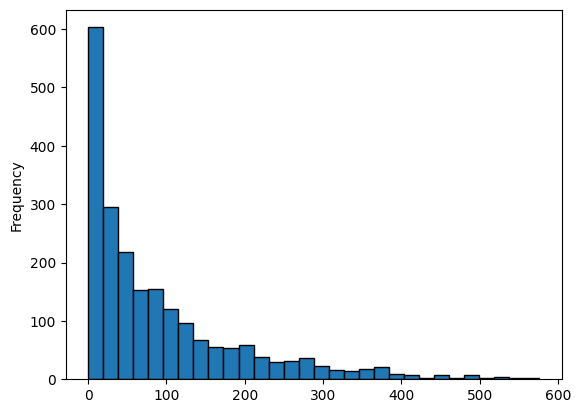

In [126]:
subs2['days_until_churn'].plot(kind='hist', bins=30, edgecolor='black')

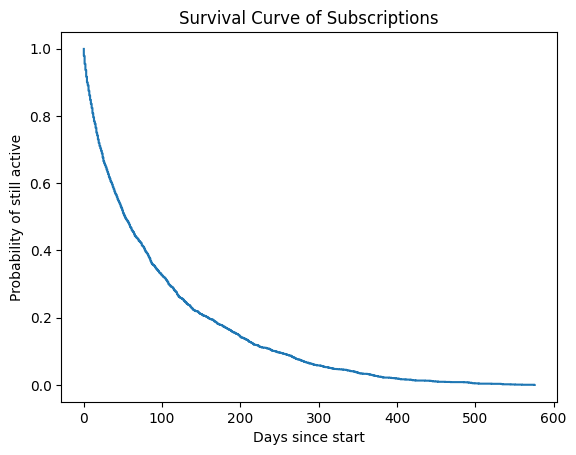

In [127]:
durations = np.sort(subs2['days_until_churn'].dropna())
survival_prob = 1 - np.arange(1, len(durations)+1)/len(durations)

plt.step(durations, survival_prob, where="post")
plt.title("Survival Curve of Subscriptions")
plt.xlabel("Days since start")
plt.ylabel("Probability of still active")
plt.show()

In [113]:
(subs2['days_until_churn'] == 0).sum() # gives 46 records where subscription started on the same day as churn event
# subs2[subs2['days_until_churn'] == 0][['start_date', 'churn_date', 'days_until_churn']]


np.int64(46)

- we now form column for classifying 'days_until_churn' in a predefined window of 0-30 days - critical, 31-90 days - warning, 91-180 days - stable, 181+ long-term

In [10]:
bins = [0, 30, 90, 180, float('inf')]
labels = ['0-30 days', '31-90 days', '91-180 days', '180+ days']

In [11]:
subs2['churn_timeframe'] = pd.cut(subs2['days_until_churn'], bins=bins, labels=labels)

In [12]:
# Explicitly label the ones that never churned (NaNs)
subs2['churn_timeframe'] = subs2['churn_timeframe'].cat.add_categories('No Churn')
subs2['churn_timeframe'].fillna('No Churn', inplace=True)

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_13816\2157885675.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  subs2['churn_timeframe'].fillna('No Churn', inplace=True)


In [123]:
subs2.head(10)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn,churn_timeframe
0,S-92f228,A-779e4e,2023-01-09,NaN,Basic,9,171,2052,False,False,False,False,annual,True,NaT,False,NaN,No Churn
1,S-50aaaa,A-af0cd2,2023-01-12,NaN,Pro,19,931,11172,False,False,False,False,monthly,True,2023-10-26,True,287.0,180+ days
2,S-18356d,A-779e4e,2023-01-28,NaN,Enterprise,18,3582,42984,False,True,False,False,annual,True,NaT,False,NaN,No Churn
3,S-fa9b43,A-10b8f2,2023-02-05,NaN,Basic,47,0,0,True,False,False,False,annual,False,2024-06-04,True,485.0,180+ days
4,S-6676fa,A-7df7a7,2023-02-05,NaN,Pro,7,343,4116,False,False,True,False,monthly,True,2024-07-10,True,521.0,180+ days
5,S-47ce2d,A-d792a6,2023-02-06,NaN,Pro,37,1813,21756,False,False,False,False,monthly,True,2023-09-11,True,217.0,180+ days
6,S-11066a,A-779e4e,2023-02-12,2023-11-24,Pro,19,931,11172,False,False,False,True,annual,True,NaT,False,NaN,No Churn
7,S-7de656,A-f17767,2023-02-15,2023-08-25,Pro,14,686,8232,False,False,False,True,annual,True,2023-05-03,True,77.0,31-90 days
8,S-7a36ee,A-b11cd0,2023-02-16,2024-06-22,Basic,26,494,5928,False,False,False,True,monthly,True,NaT,False,NaN,No Churn
9,S-78c894,A-d792a6,2023-02-17,NaN,Basic,4,76,912,False,True,False,False,annual,True,2023-09-11,True,206.0,180+ days


#### plan_tier

conclusions

- basic tier is proportional with 30-34% across all the timeframe active as a baseline tier
- pro tier is more valatile - immediate or long-term churn, stable in 30-90 days
- enterprises prone to churn in 30-90 days, else stable and have large share in No-Churn group

In [125]:
pd.crosstab(subs2['churn_timeframe'], subs2['plan_tier'], normalize='index') * 100

plan_tier,Basic,Enterprise,Pro
churn_timeframe,,,
0-30 days,30.417227,32.166891,37.415882
31-90 days,34.219269,36.877076,28.903654
91-180 days,32.142857,33.163265,34.693878
180+ days,34.146341,30.894309,34.959350
No Churn,31.720802,35.176227,33.102972


#### end_date

- we calculate how many days after the end of a subscription did the customer churned - churn_date - end_date

conclusions

- 112 accounts churned before their subs ended
- 105 accounts ended after subs ended i.e. they were active and staying the 'grace period'
- for the 105 accounts we could have used this 'grace period' stay as retention opportunity

Note
- this columns 'end_date' in subs table isn't reliable since the subs having end_date as a signal to the end of that subscription are actually active as found out in the feature_usage table.

In [13]:
subs2['end_date'] = pd.to_datetime(subs2['end_date'])

In [130]:
subs2['days_after_end_subs'] = (subs2['churn_date'] - subs2['end_date']).dt.days

In [146]:
subs2[subs2['account_id'] == 'A-180abf']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn,churn_timeframe,days_after_end_subs
301,S-a5a40b,A-180abf,2023-09-16,2023-11-06,Enterprise,64,12736,152832,False,False,False,True,annual,False,2023-12-04,True,79.0,31-90 days,28.0
741,S-0b0ffa,A-180abf,2024-01-17,2024-04-19,Basic,64,0,0,True,False,False,True,annual,True,2024-03-09,True,52.0,31-90 days,-41.0
895,S-8b0498,A-180abf,2024-02-19,NaT,Pro,64,3136,37632,False,False,False,False,monthly,False,2024-03-09,True,19.0,0-30 days,NaN
1233,S-612bfb,A-180abf,2024-04-16,NaT,Enterprise,64,12736,152832,False,True,False,False,annual,True,2024-05-04,True,18.0,0-30 days,NaN
1915,S-fa05d7,A-180abf,2024-07-10,NaT,Basic,64,1216,14592,False,False,False,False,monthly,True,2024-09-12,True,64.0,31-90 days,NaN
3576,S-b262a1,A-180abf,2024-11-09,NaT,Basic,64,1216,14592,False,False,False,False,annual,True,NaT,False,NaN,No Churn,NaN
4460,S-0aba5b,A-180abf,2024-12-16,NaT,Pro,64,0,0,True,False,False,False,monthly,True,NaT,False,NaN,No Churn,NaN
4491,S-85f2ab,A-180abf,2024-12-17,NaT,Pro,64,3136,37632,False,False,False,False,monthly,True,NaT,False,NaN,No Churn,NaN
4591,S-e9395e,A-180abf,2024-12-20,NaT,Pro,64,3136,37632,False,True,False,False,monthly,True,NaT,False,NaN,No Churn,NaN


In [142]:
print(f"accounts_churned_before_subs_end = {subs2[subs2['days_after_end_subs'] < 0].shape[0]}, accounts_churned_after_subs_end = {subs2[subs2['days_after_end_subs'] >= 0].shape[0]}")

accounts_churned_before_subs_end = 112, accounts_churned_after_subs_end = 105


In [224]:
subs2[subs2['end_date'].notnull() & subs2['churn_date'].notnull()][['start_date', 'end_date', 'churn_date']].head(5).sort_values('end_date')

,start_date,end_date,churn_date
2188,2024-08-04,2024-08-23,2024-10-31
2675,2024-09-15,2024-09-19,2024-10-31
3052,2024-10-10,2024-11-16,2024-10-31
3713,2024-11-16,2024-11-20,2024-11-26
4554,2024-12-19,2024-12-30,2024-12-22


In [229]:
subs2[subs2['end_date'].notnull() & subs2['churn_date'].notnull()][['start_date', 'end_date', 'churn_date', 'auto_renew_flag']].head(5).sort_values('end_date')

,start_date,end_date,churn_date,auto_renew_flag
2188,2024-08-04,2024-08-23,2024-10-31,False
2675,2024-09-15,2024-09-19,2024-10-31,False
3052,2024-10-10,2024-11-16,2024-10-31,True
3713,2024-11-16,2024-11-20,2024-11-26,True
4554,2024-12-19,2024-12-30,2024-12-22,True


#### seats

test

- does the seats drop as the timeframe gets closer to 0?

conclusion 

- seats drop from 180+ days to near 30 days 
- strangely for the critical zone i.e. 0-30 days there is rise in seat counts - suggesting 'last attempt' for to the product, or seats increased by administration for data transfer before churn
- seats change over the time alone doesn't help in churn driving could be a possible conclusion from this strange behavior

In [150]:
subs2.groupby('churn_timeframe')['seats'].describe()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_42696\3922644872.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subs2.groupby('churn_timeframe')['seats'].describe()


,count,mean,std,min,25%,50%,75%,max
churn_timeframe,,,,,,,,
0-30 days,743.0,30.520861,25.180840,1.0,13.5,24.0,40.00,179.0
31-90 days,602.0,27.124585,21.035413,1.0,12.0,22.0,34.75,163.0
91-180 days,392.0,27.956633,21.891868,1.0,13.0,23.0,37.00,136.0
180+ days,369.0,29.991870,22.543254,2.0,14.0,24.0,41.00,189.0
No Churn,2894.0,30.486524,23.123969,1.0,14.0,25.0,40.00,170.0


<Axes: xlabel='churn_timeframe', ylabel='seats'>

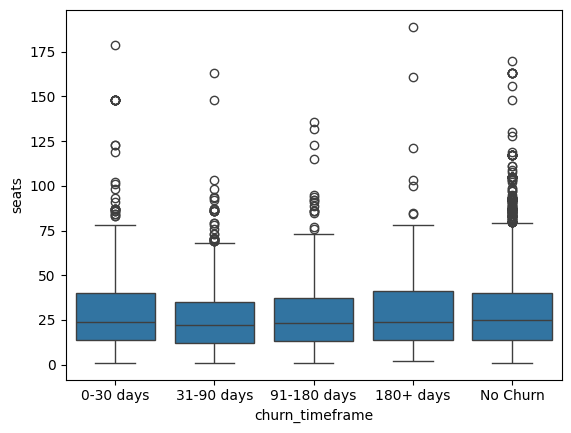

In [148]:
sns.boxplot(x='churn_timeframe', y='seats', data=subs2)

<Axes: xlabel='churn_timeframe', ylabel='seats'>

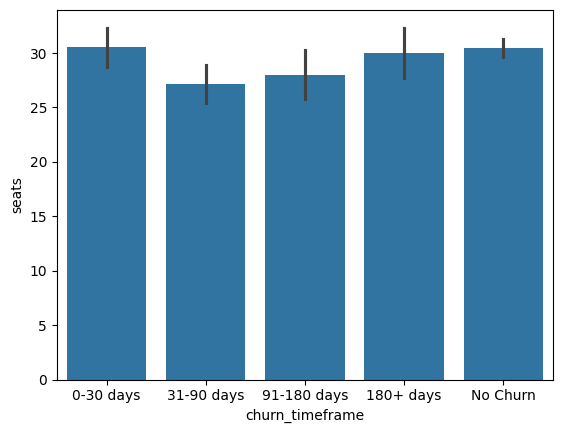

In [186]:
sns.barplot(x='churn_timeframe', y='seats', data=subs2)

<Axes: xlabel='churn_timeframe', ylabel='seats'>

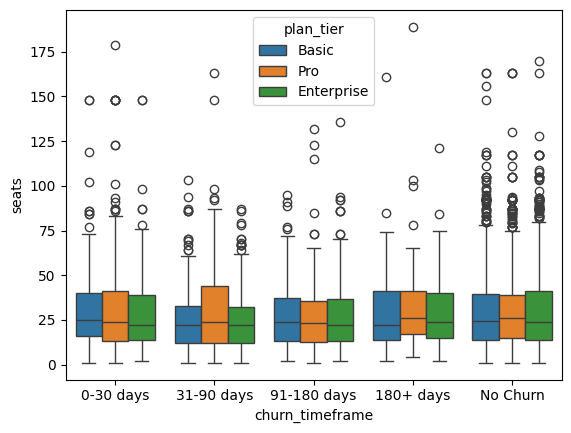

In [149]:
sns.boxplot(x='churn_timeframe', y='seats', hue='plan_tier', data=subs2)

In [161]:
subs2 = subs2.sort_values(['account_id', 'start_date'])

In [162]:
subs2.groupby('account_id')['seats'].diff()

475      NaN
1176   -33.0
1371     0.0
1438    21.0
1977   -21.0
        ... 
3248   -85.0
3306    -3.0
3731    26.0
3899   -26.0
4621    -1.0
Name: seats, Length: 5000, dtype: float64

In [163]:
subs2['seat_change'] = subs2.groupby('account_id')['seats'].diff()

In [167]:
subs2.head(10)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn,churn_timeframe,days_after_end_subs,seat_change
475,S-a7360b,A-00bed1,2023-11-16,NaT,Basic,61,1159,13908,False,True,False,False,annual,True,2024-01-03,True,48.0,31-90 days,NaN,NaN
1176,S-3fbf9e,A-00bed1,2024-04-06,NaT,Pro,28,1372,16464,False,False,False,False,monthly,True,NaT,False,NaN,No Churn,NaN,-33.0
1371,S-585d4c,A-00bed1,2024-05-06,NaT,Enterprise,28,5572,66864,False,True,False,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0
1438,S-76a214,A-00bed1,2024-05-14,NaT,Enterprise,49,9751,117012,False,False,False,False,annual,True,NaT,False,NaN,No Churn,NaN,21.0
1977,S-64fba3,A-00bed1,2024-07-16,NaT,Enterprise,28,5572,66864,False,False,False,False,annual,True,NaT,False,NaN,No Churn,NaN,-21.0
2022,S-7f9ce5,A-00bed1,2024-07-20,NaT,Pro,28,1372,16464,False,False,False,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0
2214,S-4a724b,A-00bed1,2024-08-06,NaT,Pro,28,1372,16464,False,False,False,False,annual,True,NaT,False,NaN,No Churn,NaN,0.0
2342,S-a86344,A-00bed1,2024-08-18,NaT,Pro,36,1764,21168,False,True,False,False,annual,True,NaT,False,NaN,No Churn,NaN,8.0
2446,S-f3dd83,A-00bed1,2024-08-28,NaT,Enterprise,28,0,0,True,False,False,False,monthly,True,NaT,False,NaN,No Churn,NaN,-8.0
2491,S-289702,A-00bed1,2024-09-01,NaT,Enterprise,28,5572,66864,False,False,False,False,annual,False,NaT,False,NaN,No Churn,NaN,0.0


<Axes: xlabel='churn_timeframe', ylabel='seat_change'>

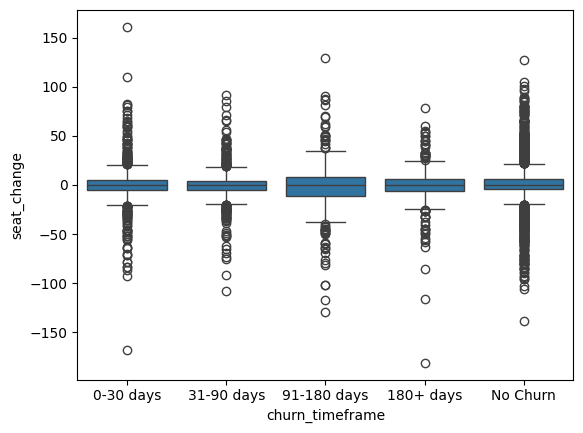

In [164]:
sns.boxplot(x='churn_timeframe', y='seat_change', data=subs2)

In [184]:
subs2[subs2['account_id'] == 'A-180abf']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn,churn_timeframe,days_after_end_subs,seat_change,mrr_change
301,S-a5a40b,A-180abf,2023-09-16,2023-11-06,Enterprise,64,12736,152832,False,False,...,True,annual,False,2023-12-04,True,79.0,31-90 days,28.0,NaN,NaN
741,S-0b0ffa,A-180abf,2024-01-17,2024-04-19,Basic,64,0,0,True,False,...,True,annual,True,2024-03-09,True,52.0,31-90 days,-41.0,0.0,-12736.0
895,S-8b0498,A-180abf,2024-02-19,NaT,Pro,64,3136,37632,False,False,...,False,monthly,False,2024-03-09,True,19.0,0-30 days,NaN,0.0,3136.0
1233,S-612bfb,A-180abf,2024-04-16,NaT,Enterprise,64,12736,152832,False,True,...,False,annual,True,2024-05-04,True,18.0,0-30 days,NaN,0.0,9600.0
1915,S-fa05d7,A-180abf,2024-07-10,NaT,Basic,64,1216,14592,False,False,...,False,monthly,True,2024-09-12,True,64.0,31-90 days,NaN,0.0,-11520.0
3576,S-b262a1,A-180abf,2024-11-09,NaT,Basic,64,1216,14592,False,False,...,False,annual,True,NaT,False,NaN,No Churn,NaN,0.0,0.0
4460,S-0aba5b,A-180abf,2024-12-16,NaT,Pro,64,0,0,True,False,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,-1216.0
4491,S-85f2ab,A-180abf,2024-12-17,NaT,Pro,64,3136,37632,False,False,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,3136.0
4591,S-e9395e,A-180abf,2024-12-20,NaT,Pro,64,3136,37632,False,True,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,0.0


#### upgrade/downgrade_flag

test 
- do downgrade spikes before churn?

conclusions
- Downgrade activity shows a slight increase closer to churn, suggesting customers tend to reduce their commitment before leaving.
- Upgrade activity peaks in mid-lifecycle (31–90 days before churn) and decreases as churn approaches, indicating reduced growth behavior prior to churn.
- Overall, customers exhibit slow expansion and mild contraction before churn, making upgrade/downgrade behavior a moderately useful signal when combined with other features.

In [ ]:
subs2.groupby('churn_timeframe')['downgrade_flag'].mean()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_42696\485000046.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subs2.groupby('churn_timeframe')['downgrade_flag'].mean()


churn_timeframe
0-30 days      0.053836
31-90 days     0.048173
91-180 days    0.033163
180+ days      0.040650
No Churn       0.041811
Name: downgrade_flag, dtype: float64

In [171]:
subs2.groupby('churn_timeframe')['upgrade_flag'].mean()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_42696\3976421072.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subs2.groupby('churn_timeframe')['upgrade_flag'].mean()


churn_timeframe
0-30 days      0.094213
31-90 days     0.122924
91-180 days    0.109694
180+ days      0.094851
No Churn       0.106082
Name: upgrade_flag, dtype: float64

#### billing_frequency

test
- do customers switch to monthly before churn

conclusion
- across timeframe the distribution of annual and montly frequency doesn't have much difference

In [173]:
pd.crosstab(
    subs2['churn_timeframe'],
    subs2['billing_frequency'],
    normalize='index'
) * 100

billing_frequency,annual,monthly
churn_timeframe,,
0-30 days,48.183042,51.816958
31-90 days,50.000000,50.000000
91-180 days,48.214286,51.785714
180+ days,49.051491,50.948509
No Churn,49.481686,50.518314


#### auto_renew_flag

test
- do customers turn off auto_renew before churn?

conclusion
- due to 80% overall true auto_renew_signal we see more true signals in every timeframe
- but auto_renew flag shows drop in auto_renew flag when nearing 0-30 days from the earlier timeframe of 30-90 or 90-180 days of about 2-3%
- still not a significant difference to suggest churn

In [188]:
pd.crosstab(
    subs2['churn_timeframe'],
    subs2['auto_renew_flag'],
    normalize='columns'
) * 100

auto_renew_flag,False,True
churn_timeframe,,
0-30 days,13.065327,15.305868
31-90 days,11.959799,12.059925
91-180 days,9.145729,7.515605
180+ days,6.532663,7.590512
No Churn,59.296482,57.528090


#### mrr_amount/arr_amount

test 
- do mrr_amount drops when nearing churn

conclusion
- MRR change shows a weak but noticeable shift near churn.
- However, the distributions largely overlap, indicating that MRR change alone is not a strong predictor of churn.

<Axes: xlabel='before_churn', ylabel='mrr_amount'>

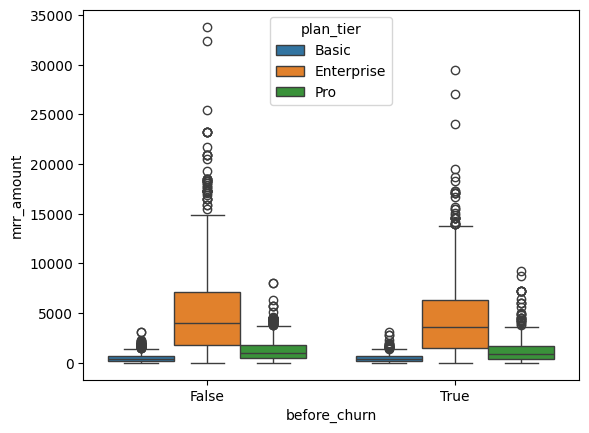

In [14]:
sns.boxplot(x='before_churn', y='mrr_amount', data=subs2, hue='plan_tier')

<Axes: xlabel='churn_timeframe', ylabel='mrr_amount'>

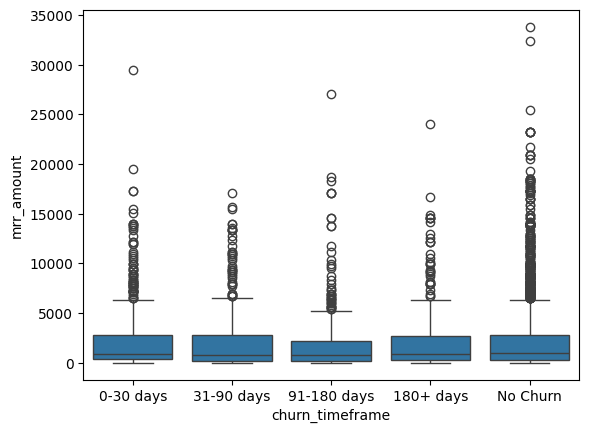

In [176]:
sns.boxplot(x='churn_timeframe', y='mrr_amount', data=subs2)

<Axes: xlabel='churn_timeframe', ylabel='arr_amount'>

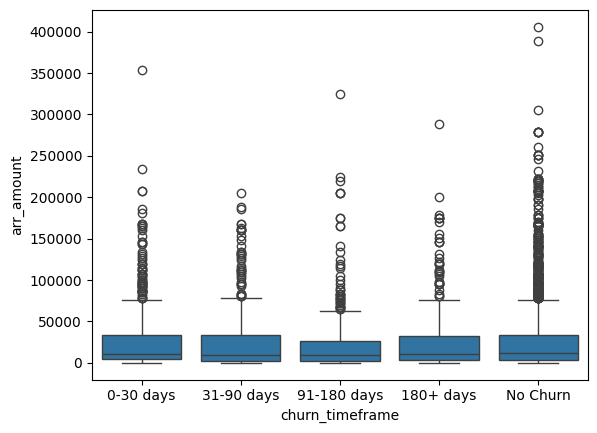

In [177]:
sns.boxplot(x='churn_timeframe', y='arr_amount', data=subs2)

In [182]:
subs2.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn,churn_timeframe,days_after_end_subs,seat_change,mrr_change
475,S-a7360b,A-00bed1,2023-11-16,NaT,Basic,61,1159,13908,False,True,...,False,annual,True,2024-01-03,True,48.0,31-90 days,NaN,NaN,NaN
1176,S-3fbf9e,A-00bed1,2024-04-06,NaT,Pro,28,1372,16464,False,False,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,-33.0,213.0
1371,S-585d4c,A-00bed1,2024-05-06,NaT,Enterprise,28,5572,66864,False,True,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,4200.0
1438,S-76a214,A-00bed1,2024-05-14,NaT,Enterprise,49,9751,117012,False,False,...,False,annual,True,NaT,False,NaN,No Churn,NaN,21.0,4179.0
1977,S-64fba3,A-00bed1,2024-07-16,NaT,Enterprise,28,5572,66864,False,False,...,False,annual,True,NaT,False,NaN,No Churn,NaN,-21.0,-4179.0


In [179]:
subs2['mrr_change'] = subs2.groupby('account_id')['mrr_amount'].diff()

<Axes: xlabel='churn_timeframe', ylabel='mrr_change'>

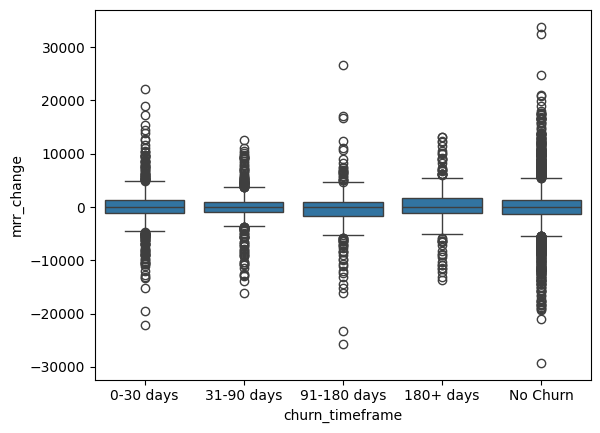

In [181]:
sns.boxplot(x='churn_timeframe', y='mrr_change', data=subs2)

In [183]:
subs2[subs2['account_id'] == 'A-0dbdc6']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn,churn_timeframe,days_after_end_subs,seat_change,mrr_change
117,S-8e169f,A-0dbdc6,2023-06-14,NaT,Pro,30,0,0,True,False,...,False,annual,True,2023-11-26,True,165.0,91-180 days,NaN,NaN,NaN
437,S-4fd561,A-0dbdc6,2023-11-04,NaT,Basic,30,570,6840,False,False,...,False,monthly,True,2023-11-26,True,22.0,0-30 days,NaN,0.0,570.0
1017,S-e92512,A-0dbdc6,2024-03-13,NaT,Basic,30,570,6840,False,False,...,False,monthly,True,2024-04-14,True,32.0,31-90 days,NaN,0.0,0.0
1281,S-61d573,A-0dbdc6,2024-04-24,NaT,Pro,30,1470,17640,False,False,...,False,annual,True,NaT,False,NaN,No Churn,NaN,0.0,900.0
1365,S-8ae804,A-0dbdc6,2024-05-05,NaT,Enterprise,50,9950,119400,False,False,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,20.0,8480.0
1836,S-d07886,A-0dbdc6,2024-07-02,NaT,Pro,30,1470,17640,False,False,...,False,annual,True,NaT,False,NaN,No Churn,NaN,-20.0,-8480.0
3318,S-73fc8f,A-0dbdc6,2024-10-25,NaT,Enterprise,30,5970,71640,False,False,...,False,monthly,False,NaT,False,NaN,No Churn,NaN,0.0,4500.0
3333,S-c0a7d8,A-0dbdc6,2024-10-26,NaT,Enterprise,30,5970,71640,False,False,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,0.0
4426,S-de3416,A-0dbdc6,2024-12-15,NaT,Pro,47,2303,27636,False,False,...,False,annual,True,NaT,False,NaN,No Churn,NaN,17.0,-3667.0


## feature_usage

test 
- feature_name and usage_count
  - increasing feature breadth - more unique feature
  - usage count drop for most used feature and rise for uncommon feature
- error_count
  - increase error counts overall for every feature
  - error counts rise in is_beat_feature leading to churn
- usage_duration_secs
  - drop in usage secs with increasing error count
  - drop in usage_Count with decreasing duration_secs

conclusion:
- we found out that while we are nearing churn the no. of feature count on average is decreasing across the horizon we have set.
- errors are very rare so not much significant trend to follow and the same happens with is_beta_feature due to very rare occurences
- usage_duration seconds is simply identical across the decided horizon suggesting no durations seconds drop while nearing churn

In [2]:
import pandas as pd

In [3]:
feat_usage = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_feature_usage.csv")

In [3]:
feat_usage['usage_date'].min(), feat_usage['usage_date'].max()

('2023-01-01', '2024-12-31')

In [5]:
accounts['signup_date'].min(), accounts['signup_date'].max()

('2023-01-02', '2024-12-31')

In [6]:
subs['start_date'].min(), subs['start_date'].max()

('2023-01-09', '2024-12-31')

In [ ]:
feat_usage.sample(5)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
6038,U-67f60a,S-f32440,2024-08-22,feature_13,8,3928,0,False
18536,U-d5820f,S-bdf4de,2024-11-17,feature_18,10,1200,2,True
8776,U-3e4ab9,S-cc3f3d,2023-09-19,feature_11,10,2870,0,False
23964,U-bdc1c9,S-bdac36,2024-01-20,feature_18,6,1500,0,False
16745,U-06734b,S-2e2d6c,2024-05-06,feature_33,8,3688,0,True


### raw table analysis

- out of 40 features on average each feature usage is ~625, follows normal distribution
- mean usage count per feature is around ~9 
- mostly feature usage seconds lasts around ~3000secs on average and few outliers exist 
- mostly usages are error free with a mean of ~0.5, few have multiple errors per usage
- around 10% are beta feature

In [194]:
# feat_usage['feature_name'].value_counts().shape
feat_usage['feature_name'].nunique()

40

In [198]:
feat_usage['feature_name'].value_counts().describe()

count     40.000000
mean     625.000000
std       24.095962
min      563.000000
25%      611.750000
50%      630.000000
75%      643.000000
max      659.000000
Name: count, dtype: float64

<Axes: ylabel='feature_name'>

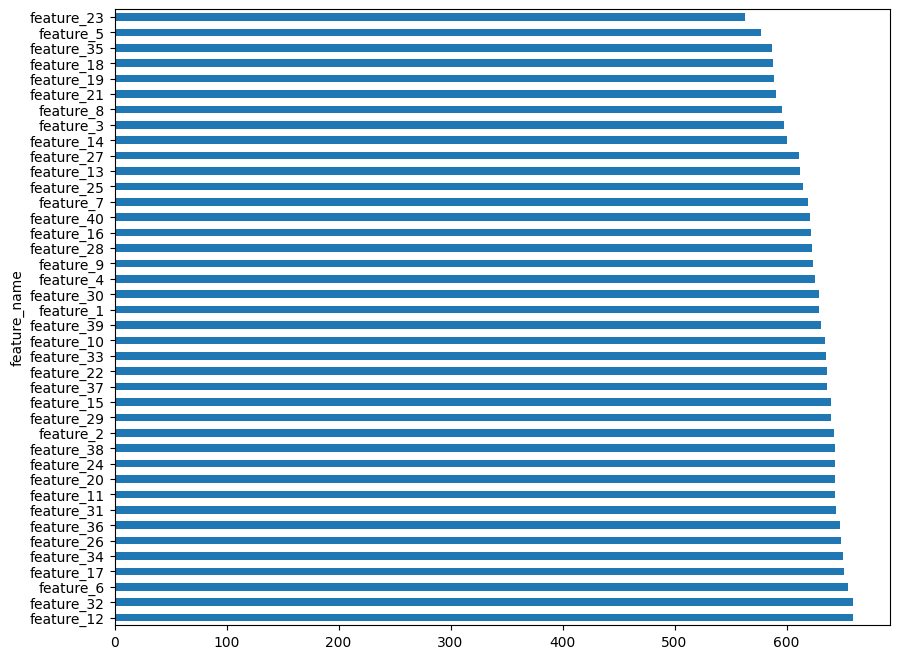

In [197]:
feat_usage['feature_name'].value_counts().plot(kind='barh', figsize=(10, 8))

In [206]:
feat_usage.groupby('feature_name')['usage_count'].describe()

,count,mean,std,min,25%,50%,75%,max
feature_name,,,,,,,,
feature_1,629.0,10.117647,3.142399,2.0,8.00,10.0,12.0,21.0
feature_10,634.0,10.069401,3.032980,1.0,8.00,10.0,12.0,20.0
feature_11,643.0,10.160187,3.053138,2.0,8.00,10.0,12.0,20.0
feature_12,659.0,9.915023,3.097023,2.0,8.00,10.0,12.0,23.0
feature_13,612.0,9.965686,3.144704,2.0,8.00,10.0,12.0,21.0
feature_14,600.0,9.800000,3.173871,1.0,7.75,10.0,12.0,20.0
feature_15,640.0,10.345313,3.275242,2.0,8.00,10.0,13.0,21.0
feature_16,622.0,10.085209,3.225923,2.0,8.00,10.0,12.0,24.0
feature_17,651.0,9.920123,3.192261,1.0,8.00,10.0,12.0,26.0


<Axes: ylabel='Frequency'>

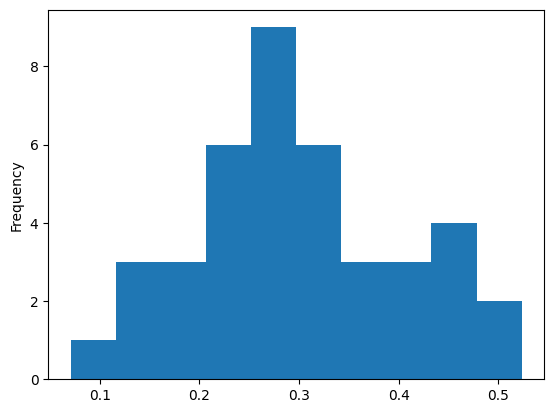

In [ ]:
feat_usage.groupby('feature_name')['usage_count'].skew().plot(kind='hist')

In [209]:
feat_usage['usage_duration_secs'].describe()

count    25000.000000
mean      3042.202880
std       2056.544615
min          0.000000
25%       1350.000000
50%       2760.000000
75%       4400.000000
max      12696.000000
Name: usage_duration_secs, dtype: float64

<Axes: ylabel='Frequency'>

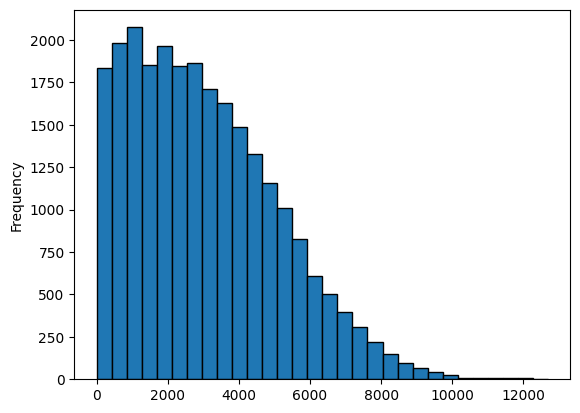

In [210]:
feat_usage['usage_duration_secs'].plot(kind='hist', bins=30, edgecolor='black')

In [211]:
feat_usage['error_count'].describe()

count    25000.000000
mean         0.564280
std          1.012595
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          8.000000
Name: error_count, dtype: float64

In [215]:
feat_usage['is_beta_feature'].value_counts(normalize=True) * 100

is_beta_feature
False    89.824
True     10.176
Name: proportion, dtype: float64

In [217]:
feat_usage.groupby('is_beta_feature')[['usage_duration_secs','error_count']].mean()

,usage_duration_secs,error_count
is_beta_feature,,
False,3041.384129,0.565150
True,3049.430031,0.556604


### churn-aware analysis



In [17]:
feat_usage.head(3)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False


- we first put the 'churn_date' column in feature_usage to analyse the 'before churn behavior'

In [4]:
# copying the feat_usage in a new dataframe to avoid any changes in the original dataframe
usage = feat_usage.copy()

In [5]:
usage.head(3)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False


In [17]:
# convert all the datetime columns to datetime type
for df, col in [(subs2, 'start_date'), (subs2, 'end_date'), (churn_events2, 'churn_date'), (usage, 'usage_date')]:
    df[col] = pd.to_datetime(df[col])

for dtype in [subs2['start_date'].dtype, subs2['end_date'].dtype, churn_events2['churn_date'].dtype, usage['usage_date'].dtype]:
    display(dtype)

dtype('<M8[ns]')

dtype('<M8[ns]')

dtype('<M8[ns]')

dtype('<M8[ns]')

In [18]:
# let's get the account_id in feat_usage - this will help to get the churn_date when merging with churn_events
usage = usage.merge(subs2[['subscription_id', 'account_id']], on='subscription_id', how='left')

In [19]:
usage.shape

(25000, 9)

In [23]:
usage.sample(3)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id
468,U-33ebe1,S-c18476,2023-07-13,feature_7,22,176,0,False,A-40906c
7288,U-390660,S-d841e4,2024-07-10,feature_39,9,45,0,False,A-a1b80b
10010,U-eb5263,S-b39049,2024-08-22,feature_4,8,2168,0,True,A-4e44e8


In [20]:
# let's merge_asof by account_id with churn_events to get the nearest churn_date for each usage record
usage = pd.merge_asof(
    usage.sort_values('usage_date'),
    churn_events2[['account_id', 'churn_date']].sort_values('churn_date'),
    by='account_id',
    left_on='usage_date',
    right_on='churn_date',
    direction='forward'
)

In [25]:
usage.sample(5)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date
21377,U-fdd47e,S-61a647,2024-09-18,feature_35,6,3168,0,False,A-726cfa,NaT
9300,U-9f7006,S-d2d423,2023-09-29,feature_6,12,1656,0,True,A-72799b,2024-05-05
20423,U-303134,S-f30081,2024-08-21,feature_14,8,2144,2,False,A-cb5333,NaT
4123,U-f59d77,S-079321,2023-04-29,feature_34,4,1360,2,False,A-e1462e,2023-10-05
22019,U-49a3a0,S-046595,2024-10-07,feature_6,6,1164,0,False,A-ed510f,NaT


In [26]:
# churn_events2[churn_events2['account_id'] == 'A-2e3bad']
churn_events2[churn_events2['account_id'] == 'A-180abf']

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
23,C-e582ea,A-180abf,2023-12-04,support,0.0,False,False,False,NaN
155,C-2b7d9b,A-180abf,2024-03-09,support,0.0,False,True,False,NaN
425,C-e41103,A-180abf,2024-05-04,competitor,0.0,False,False,False,NaN
424,C-6a6704,A-180abf,2024-05-08,support,0.0,False,False,False,switched to competitor
80,C-fab429,A-180abf,2024-09-12,support,0.0,False,False,False,NaN


below cell confirms that the usage records have been set to the nearest churn_date

In [28]:
# this confirms that the usage records have been set to the nearest churn_date
usage[usage['account_id'] == 'A-180abf'][usage['churn_date'] == '2023-12-04']

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_22168\2821538452.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  usage[usage['account_id'] == 'A-180abf'][usage['churn_date'] == '2023-12-04']


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date
673,U-1835ec,S-612bfb,2023-01-19,feature_20,14,4816,2,False,A-180abf,2023-12-04
2645,U-2cd45b,S-612bfb,2023-03-17,feature_9,10,5440,0,False,A-180abf,2023-12-04
2731,U-8ce730,S-fa05d7,2023-03-20,feature_14,11,4939,0,False,A-180abf,2023-12-04
3037,U-919e84,S-8b0498,2023-03-28,feature_3,6,990,0,False,A-180abf,2023-12-04
3461,U-0f7081,S-a5a40b,2023-04-10,feature_31,11,4752,0,False,A-180abf,2023-12-04
4300,U-30a9d0,S-a5a40b,2023-05-04,feature_18,14,4704,0,False,A-180abf,2023-12-04
4570,U-71f221,S-0aba5b,2023-05-13,feature_15,6,1206,0,False,A-180abf,2023-12-04
4737,U-ca4b5f,S-fa05d7,2023-05-17,feature_37,10,1240,0,False,A-180abf,2023-12-04
5161,U-149217,S-612bfb,2023-05-29,feature_25,19,7410,0,False,A-180abf,2023-12-04
5606,U-b952f1,S-b262a1,2023-06-11,feature_17,6,258,1,True,A-180abf,2023-12-04


since the usage is of each subscription, we also need to assess the behavior before each subscriptions end.

problem
- large no. of active subcriptions
  - in subscription table we have many subcriptions activated before a particular churn_event are active even after that particular churn_event - logically they should end when the accounts churn but are still active.
- end_date > churn_date
  - we have subscription activated before a particular churn which have end_date after the churn_date of that particular churn (possibly indicating the subcription ended gracefully after the contracts ends).

test
- let's pick few accounts and see if active subscription which should have ended with the nearest churn are still being used after that nearest churn.
  - if Yes then it proves those subscription are still active and accounts are still using those subscriptions and there is no point in ending those subscription.
  - if No then we surely know that the system has failed to mark those subcription as ended with an end_date and they are still being shown as active_plans with no end_date.

results
- the subscriptions which we thought were inactive since the customer had churn they are still being used suggesting once the customer reactivated the account those subscription are resumed.
- also we found out that the end_date of subscription mentioned in the subscription table is not reliable, since those subscription are still being used even after the end_date as noticed in the usage table below.

In [246]:
subs2[subs2['account_id'] == 'A-180abf']

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,churn_flag,billing_frequency,auto_renew_flag,churn_date,before_churn,days_until_churn,churn_timeframe,days_after_end_subs,seat_change,mrr_change
301,S-a5a40b,A-180abf,2023-09-16,2023-11-06,Enterprise,64,12736,152832,False,False,...,True,annual,False,2023-12-04,True,79.0,31-90 days,28.0,NaN,NaN
741,S-0b0ffa,A-180abf,2024-01-17,2024-04-19,Basic,64,0,0,True,False,...,True,annual,True,2024-03-09,True,52.0,31-90 days,-41.0,0.0,-12736.0
895,S-8b0498,A-180abf,2024-02-19,NaT,Pro,64,3136,37632,False,False,...,False,monthly,False,2024-03-09,True,19.0,0-30 days,NaN,0.0,3136.0
1233,S-612bfb,A-180abf,2024-04-16,NaT,Enterprise,64,12736,152832,False,True,...,False,annual,True,2024-05-04,True,18.0,0-30 days,NaN,0.0,9600.0
1915,S-fa05d7,A-180abf,2024-07-10,NaT,Basic,64,1216,14592,False,False,...,False,monthly,True,2024-09-12,True,64.0,31-90 days,NaN,0.0,-11520.0
3576,S-b262a1,A-180abf,2024-11-09,NaT,Basic,64,1216,14592,False,False,...,False,annual,True,NaT,False,NaN,No Churn,NaN,0.0,0.0
4460,S-0aba5b,A-180abf,2024-12-16,NaT,Pro,64,0,0,True,False,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,-1216.0
4491,S-85f2ab,A-180abf,2024-12-17,NaT,Pro,64,3136,37632,False,False,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,3136.0
4591,S-e9395e,A-180abf,2024-12-20,NaT,Pro,64,3136,37632,False,True,...,False,monthly,True,NaT,False,NaN,No Churn,NaN,0.0,0.0


In [247]:
usage[usage['subscription_id'] == 'S-8b0498']

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date
3037,U-919e84,S-8b0498,2023-03-28,feature_3,6,990,0,False,A-180abf,2023-12-04
6437,U-bc66b5,S-8b0498,2023-07-06,feature_13,10,190,0,False,A-180abf,2023-12-04
21469,U-c4b836,S-8b0498,2024-09-21,feature_24,10,1090,2,False,A-180abf,NaT
21628,U-d85751,S-8b0498,2024-09-25,feature_12,8,3784,0,False,A-180abf,NaT


In [248]:
usage[usage['subscription_id'] == 'S-612bfb']

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date
673,U-1835ec,S-612bfb,2023-01-19,feature_20,14,4816,2,False,A-180abf,2023-12-04
2645,U-2cd45b,S-612bfb,2023-03-17,feature_9,10,5440,0,False,A-180abf,2023-12-04
5161,U-149217,S-612bfb,2023-05-29,feature_25,19,7410,0,False,A-180abf,2023-12-04
10928,U-dacb0e,S-612bfb,2023-11-17,feature_11,10,3190,0,False,A-180abf,2023-12-04
11751,U-0facab,S-612bfb,2023-12-12,feature_34,12,2088,0,False,A-180abf,2024-03-09
13844,U-196d83,S-612bfb,2024-02-10,feature_39,10,960,2,False,A-180abf,2024-03-09
18475,U-301c8a,S-612bfb,2024-06-25,feature_13,10,5720,0,False,A-180abf,2024-09-12
18561,U-5473a9,S-612bfb,2024-06-28,feature_27,14,7882,1,False,A-180abf,2024-09-12
22171,U-df5eca,S-612bfb,2024-10-11,feature_14,7,3976,0,False,A-180abf,NaT


In [249]:
usage[usage['subscription_id'] == 'S-0b0ffa']

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date
19172,U-09885b,S-0b0ffa,2024-07-15,feature_23,14,672,0,False,A-180abf,2024-09-12
20860,U-29a06e,S-0b0ffa,2024-09-03,feature_13,14,7308,0,False,A-180abf,2024-09-12


In [250]:
usage[usage['subscription_id'] == 'S-a5a40b']

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date
3461,U-0f7081,S-a5a40b,2023-04-10,feature_31,11,4752,0,False,A-180abf,2023-12-04
4300,U-30a9d0,S-a5a40b,2023-05-04,feature_18,14,4704,0,False,A-180abf,2023-12-04
6644,U-96c1be,S-a5a40b,2023-07-12,feature_2,12,4428,2,False,A-180abf,2023-12-04
7317,U-2ee8ad,S-a5a40b,2023-07-31,feature_38,10,910,2,False,A-180abf,2023-12-04
8919,U-7d65e1,S-a5a40b,2023-09-18,feature_40,13,5447,0,False,A-180abf,2023-12-04
13314,U-be44f2,S-a5a40b,2024-01-26,feature_3,9,2853,2,False,A-180abf,2024-03-09
13455,U-6255f9,S-a5a40b,2024-01-30,feature_11,9,5094,0,False,A-180abf,2024-03-09
16637,U-68ec83,S-a5a40b,2024-05-02,feature_4,13,5512,2,False,A-180abf,2024-05-04
16970,U-c76f4b,S-a5a40b,2024-05-11,feature_12,7,1869,0,False,A-180abf,2024-09-12


In [21]:
# days until churn 
usage['days_until_churn'] = (usage['churn_date'] - usage['usage_date']).dt.days
usage.sample(2)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date,days_until_churn
9073,U-55c181,S-620b62,2023-09-22,feature_3,14,5530,1,False,A-d42431,2024-06-26,278.0
6478,U-f525d7,S-88cb91,2023-07-07,feature_35,10,3050,0,False,A-cab532,2024-07-10,369.0


In [32]:
usage['days_until_churn'].describe()

count    14456.000000
mean       266.469424
std        184.846389
min          0.000000
25%        103.000000
50%        243.500000
75%        408.000000
max        729.000000
Name: days_until_churn, dtype: float64

In [22]:
# 4. Use the 30-Day Horizons (since 14-day is too sparse)
bins = [0, 30, 60, 90, 180, float('inf')]
labels = ['0-30 Days', '31-60 Days', '61-90 Days', '91-180 Days', '180+ Days']
usage['usage_horizon'] = pd.cut(usage['days_until_churn'], bins=bins, labels=labels)

In [23]:
# usage['usage_horizon'].value_counts()
usage['usage_horizon'].value_counts().sort_index()

usage_horizon
0-30 Days      1169
31-60 Days     1018
61-90 Days      957
91-180 Days    2514
180+ Days      8758
Name: count, dtype: int64

In [24]:
# calculating error_rate based on errors per usage record
usage['error_rate'] = usage['error_count'] / usage['usage_count']
usage.sample(3)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date,days_until_churn,usage_horizon,error_rate
23379,U-6cd5a9,S-4d47e3,2024-11-14,feature_4,11,3531,0,True,A-7f4db3,NaT,NaN,NaN,0.0
1537,U-4495f0,S-92f228,2023-02-15,feature_17,5,1845,0,False,A-779e4e,NaT,NaN,NaN,0.0
20073,U-bdce16,S-f0972b,2024-08-11,feature_28,7,3409,0,False,A-b7b7b7,NaT,NaN,NaN,0.0


In [43]:
usage.groupby('usage_horizon')['error_rate'].mean()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_22168\4055327938.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usage.groupby('usage_horizon')['error_rate'].mean()


usage_horizon
0-30 Days      0.066080
31-60 Days     0.064623
61-90 Days     0.064142
91-180 Days    0.065386
180+ Days      0.065458
Name: error_rate, dtype: float64

In [25]:
usage['is_high_error'] = usage['error_rate'] > 0.15

In [26]:
usage.groupby('usage_horizon')['is_high_error'].mean()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_23056\3182837096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usage.groupby('usage_horizon')['is_high_error'].mean()


usage_horizon
0-30 Days      0.159966
31-60 Days     0.166994
61-90 Days     0.160920
91-180 Days    0.166269
180+ Days      0.171843
Name: is_high_error, dtype: float64

In [27]:
usage['seconds_per_unit'] = usage['usage_duration_secs'] / usage['usage_count']

In [48]:
usage.sample(3)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date,days_until_churn,usage_horizon,error_rate,is_high_error,seconds_per_unit
16502,U-1724e7,S-42bbe0,2024-04-28,feature_35,16,6064,2,False,A-2e3bad,NaT,NaN,NaN,0.125,False,379.0
20193,U-299963,S-16b6dc,2024-08-15,feature_3,4,2364,0,False,A-794a0b,2024-09-09,25.0,0-30 Days,0.000,False,591.0
13894,U-4255b0,S-d90f5e,2024-02-12,feature_13,11,3399,0,False,A-bd4513,2024-12-07,299.0,180+ Days,0.000,False,309.0


In [52]:
usage.groupby('usage_horizon')['seconds_per_unit'].mean()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_22168\2697176044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usage.groupby('usage_horizon')['seconds_per_unit'].mean()


usage_horizon
0-30 Days      297.656116
31-60 Days     307.610020
61-90 Days     304.038662
91-180 Days    299.311058
180+ Days      305.810345
Name: seconds_per_unit, dtype: float64

<Axes: xlabel='usage_horizon', ylabel='seconds_per_unit'>

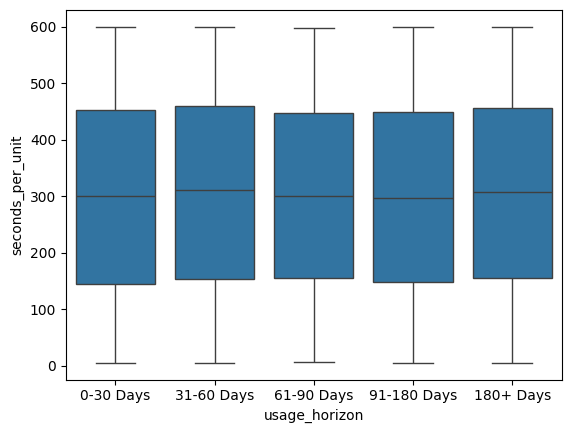

In [51]:
sns.boxplot(x=usage['usage_horizon'], y=usage['seconds_per_unit'], data=usage)

In [53]:
churn_events.groupby('account_id').size().mean()

np.float64(1.7045454545454546)

In [60]:
usage['days_until_churn'].describe()

count    14456.000000
mean       266.469424
std        184.846389
min          0.000000
25%        103.000000
50%        243.500000
75%        408.000000
max        729.000000
Name: days_until_churn, dtype: float64

In [59]:
usage.groupby(['account_id', 'churn_date'])['days_until_churn'].min().describe()

count    559.000000
mean      14.935599
std       19.303912
min        0.000000
25%        3.000000
50%        9.000000
75%       19.000000
max      160.000000
Name: days_until_churn, dtype: float64

In [ ]:
# checking the period(days) between each usage record, may help 
usage.sort_values(['account_id', 'usage_date']).groupby(['account_id', 'churn_date'])['usage_date'].diff().dt.days.describe()

count    13897.000000
mean        13.872634
std         15.345462
min          0.000000
25%          4.000000
50%          9.000000
75%         19.000000
max        192.000000
Name: usage_date, dtype: float64

In [62]:
usage[usage['churn_date'].isna()].sort_values(['account_id', 'usage_date']).groupby('account_id')['usage_date'].diff().dt.days.describe()

count    10101.000000
mean        13.997723
std         15.397489
min          0.000000
25%          4.000000
50%          9.000000
75%         19.000000
max        159.000000
Name: usage_date, dtype: float64

In [ ]:
# checking if there is use of unique feature when nearing churn and across churn horizon
usage.groupby(['usage_horizon', 'account_id', 'churn_date'], observed=True)['feature_name'].nunique().groupby('usage_horizon', observed=True).mean()

usage_horizon
0-30 Days       2.347107
31-60 Days      2.360190
61-90 Days      2.403101
91-180 Days     5.375576
180+ Days      16.706989
Name: feature_name, dtype: float64

In [ ]:
# checking if there are multiple events exist per day
# if yes then 'account_id' and 'usage_date' will be same so duplicated
# this suggest probably the users are using different features per days, since each row is single feature.
# if unique features usage exist on a single day then that is a new row on the same day
usage.duplicated(subset=['account_id', 'usage_date']).sum()

np.int64(889)

In [34]:
usage[usage.duplicated(subset=['account_id','usage_date'], keep=False)]

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_date,days_until_churn,usage_horizon,error_rate,is_high_error,seconds_per_unit
11,U-14dbc4,S-977d49,2023-01-01,feature_11,10,2870,3,True,A-a865bd,2023-11-26,329.0,180+ Days,0.300000,True,287.0
12,U-7e33d4,S-977d49,2023-01-01,feature_19,6,2142,0,False,A-a865bd,2023-11-26,329.0,180+ Days,0.000000,False,357.0
45,U-3b06d3,S-527d18,2023-01-02,feature_8,6,918,0,True,A-5b1bcd,2024-08-07,583.0,180+ Days,0.000000,False,153.0
49,U-7dc01c,S-ee4c5c,2023-01-02,feature_7,6,150,0,False,A-5b1bcd,2024-08-07,583.0,180+ Days,0.000000,False,25.0
71,U-e8629b,S-1d63bf,2023-01-03,feature_4,11,3927,0,False,A-69fad4,2024-06-17,531.0,180+ Days,0.000000,False,357.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24915,U-ab057c,S-5cb87c,2024-12-29,feature_6,10,2680,0,False,A-e89151,NaT,NaN,NaN,0.000000,False,268.0
24921,U-6f595b,S-d7ee6f,2024-12-29,feature_19,11,2673,0,False,A-35083d,NaT,NaN,NaN,0.000000,False,243.0
24936,U-35996a,S-03ac49,2024-12-29,feature_31,8,2168,0,False,A-35083d,NaT,NaN,NaN,0.000000,False,271.0
24969,U-40e4d0,S-b49c0a,2024-12-31,feature_16,8,1440,2,False,A-db5e9e,NaT,NaN,NaN,0.250000,True,180.0


In [ ]:
# checking if their average difference is significant

usage.groupby('account_id')['usage_date'].agg(
    total_events='count', 
    unique_days='nunique'
).describe()

# we can see the output, 50 events per 50 unique days, i.e. only a few ~1.78 extra events per accounts exist

,total_events,unique_days
count,500.000000,500.000000
mean,50.000000,48.222000
std,17.188685,16.197699
min,10.000000,10.000000
25%,38.000000,36.750000
50%,50.000000,48.000000
75%,62.000000,59.000000
max,101.000000,96.000000


## support_tickets

conclusions
- Satisfaction scores remain completely stable (~4.0) right up to the day of churn, proving that acute customer service frustration is not the final trigger.
- Ticket volume drops by over 50% in the final 30 days (from ~2.4 down to ~1.1 tickets). Churners don't submit more complaints before leaving; they stop asking for help entirely.

In [114]:
sup_ticks = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\raw\ravenstack_support_tickets.csv")

In [76]:
sup_ticks.sample(5)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
1321,T-772188,A-fda07f,2024-08-03,2024-08-03 10:00:00,10.0,urgent,68,5.0,False
521,T-9a1036,A-443b7c,2023-01-24,2023-01-25 07:00:00,31.0,urgent,51,5.0,False
62,T-384dcb,A-bc4d48,2024-11-18,2024-11-20 23:00:00,71.0,urgent,6,5.0,True
1611,T-7b13df,A-ac85cd,2024-08-01,2024-08-01 23:00:00,23.0,low,35,NaN,False
379,T-429ce6,A-c45b23,2024-05-30,2024-05-30 07:00:00,7.0,high,55,3.0,False


### raw table analysis

conclusion
- average resolution time is ~35 hours
- tickets distribution across all the priority levels is even with not much significant difference
- average first response time is around ~88 minutes
- most cases closed with a satisfaction score of 4 followed by 3 and the least scored is 5, but the difference is not very significant, from 4 to 3 there is a difference of 10 cases and from 3 to 5 its around 30
- around 5% tickets have been escalated i.e. were not able to resolve by initial support tier and were sent to special technical teams


In [131]:
sup_ticks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticket_id                    2000 non-null   object        
 1   account_id                   2000 non-null   object        
 2   submitted_at                 2000 non-null   datetime64[ns]
 3   closed_at                    2000 non-null   object        
 4   resolution_time_hours        2000 non-null   float64       
 5   priority                     2000 non-null   object        
 6   first_response_time_minutes  2000 non-null   int64         
 7   satisfaction_score           1175 non-null   float64       
 8   escalation_flag              2000 non-null   bool          
 9   churn_date                   1130 non-null   datetime64[ns]
 10  days_until_churn             1130 non-null   float64       
 11  ticket_horizon               1126 non-null   cat

In [78]:
sup_ticks['resolution_time_hours'].describe()

count    2000.000000
mean       35.861000
std        21.138427
min         1.000000
25%        17.000000
50%        35.000000
75%        54.000000
max        72.000000
Name: resolution_time_hours, dtype: float64

<Axes: >

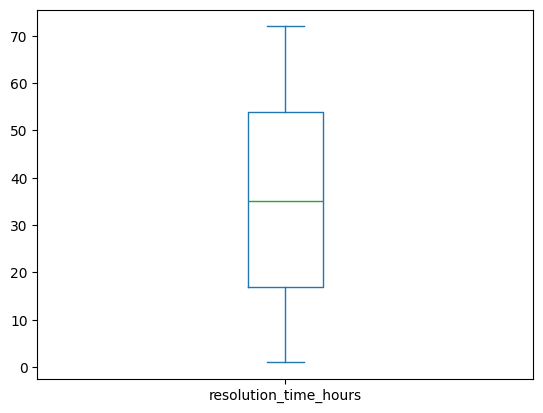

In [77]:
sup_ticks['resolution_time_hours'].plot(kind='box')

In [82]:
sup_ticks['priority'].value_counts()

priority
urgent    514
high      510
medium    491
low       485
Name: count, dtype: int64

In [83]:
sup_ticks['first_response_time_minutes'].describe()

count    2000.000000
mean       88.480000
std        51.531877
min         1.000000
25%        43.000000
50%        88.000000
75%       131.000000
max       180.000000
Name: first_response_time_minutes, dtype: float64

In [87]:
sup_ticks['satisfaction_score'].nunique()

3

In [84]:
sup_ticks['satisfaction_score'].value_counts()

satisfaction_score
4.0    405
3.0    396
5.0    374
Name: count, dtype: int64

In [98]:
(sup_ticks['escalation_flag'].value_counts()[1] / sup_ticks['escalation_flag'].value_counts()[0]) * 100

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_22168\2180576983.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (sup_ticks['escalation_flag'].value_counts()[1] / sup_ticks['escalation_flag'].value_counts()[0]) * 100


np.float64(4.986876640419948)

In [99]:
sup_ticks['escalation_flag'].value_counts()[0]

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_22168\2869073830.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sup_ticks['escalation_flag'].value_counts()[0]


np.int64(1905)

### churn-aware analysis

conclusion
- hi

In [100]:
sup_ticks.sample(3)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
735,T-30fb5e,A-34ea2f,2023-12-20,2023-12-20 11:00:00,11.0,low,158,3.0,False
44,T-219077,A-fb186e,2024-02-09,2024-02-10 18:00:00,42.0,medium,58,NaN,False
1854,T-a2665a,A-cea1f0,2024-10-11,2024-10-12 04:00:00,28.0,urgent,161,4.0,False


In [101]:
sup_ticks.groupby('priority')['resolution_time_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
priority,,,,,,,,
high,510.0,36.958824,21.429930,1.0,18.0,38.0,56.0,72.0
low,485.0,36.346392,21.577546,1.0,16.0,36.0,56.0,72.0
medium,491.0,35.594705,21.073842,1.0,17.5,34.0,53.0,72.0
urgent,514.0,34.568093,20.466495,1.0,17.0,33.0,52.0,72.0


In [104]:
pd.crosstab(sup_ticks['priority'], sup_ticks['satisfaction_score'], normalize='columns') * 100

satisfaction_score,3.0,4.0,5.0
priority,,,
high,23.484848,27.160494,24.598930
low,23.989899,22.469136,27.005348
medium,25.757576,26.419753,22.192513
urgent,26.767677,23.950617,26.203209


- Satisfaction varies by ticket priority. Urgent and medium tickets are riskier for dissatisfaction, while low priority tickets tend to yield higher satisfaction. High priority tickets sit in the middle.

In [ ]:
# looking for reason of a particular score based on the first response time
sup_ticks.groupby('satisfaction_score')['first_response_time_minutes'].mean()

satisfaction_score
3.0    86.250000
4.0    89.318519
5.0    89.962567
Name: first_response_time_minutes, dtype: float64

In [115]:
sup_ticks['submitted_at'] = pd.to_datetime(sup_ticks['submitted_at'])

In [116]:
sup_ticks = pd.merge_asof(
    sup_ticks.sort_values('submitted_at'),
    churn_events[['account_id', 'churn_date']].sort_values('churn_date'),
    by='account_id',
    left_on='submitted_at',
    right_on='churn_date',
    direction='forward'
)

In [117]:
sup_ticks.sample(5)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag,churn_date
96,T-ea95ef,A-751c58,2023-02-07,2023-02-08 08:00:00,32.0,medium,147,4.0,False,2024-09-17
1109,T-2d97f8,A-4814a3,2024-02-15,2024-02-16 00:00:00,24.0,urgent,20,4.0,False,2024-11-25
1607,T-45f75a,A-dcc3f1,2024-08-17,2024-08-18 00:00:00,24.0,high,71,NaN,False,2024-10-10
1741,T-d2e273,A-9f9299,2024-10-05,2024-10-05 05:00:00,5.0,high,94,NaN,False,2024-10-08
275,T-a952c0,A-855a48,2023-04-18,2023-04-20 00:00:00,48.0,high,125,4.0,False,2024-08-01


In [119]:
sup_ticks['days_until_chrun'] = (sup_ticks['churn_date'] - sup_ticks['submitted_at']).dt.days

In [126]:
sup_ticks.rename(columns={'days_until_chrun': 'days_until_churn'}, inplace=True)

In [127]:
sup_ticks.sample(5)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag,churn_date,days_until_churn
961,T-10fe26,A-560d27,2023-12-22,2023-12-22 04:00:00,4.0,medium,29,5.0,False,NaT,NaN
441,T-926ee8,A-5a92e7,2023-06-17,2023-06-19 20:00:00,68.0,high,9,5.0,False,2024-06-18,367.0
1768,T-f365f1,A-9779ad,2024-10-14,2024-10-15 19:00:00,43.0,medium,161,5.0,False,NaT,NaN
349,T-bf2cc6,A-e2cd1b,2023-05-12,2023-05-13 08:00:00,32.0,high,162,3.0,False,NaT,NaN
580,T-65bdba,A-8ae05d,2023-08-06,2023-08-07 23:00:00,47.0,high,48,4.0,False,2024-08-30,390.0


In [128]:
bins = [0, 30, 60, 90, 180, float('inf')]
labels = ['0-30 Days', '31-60 Days', '61-90 Days', '91-180 Days', '180+ Days']
sup_ticks['ticket_horizon'] = pd.cut(sup_ticks['days_until_churn'], bins=bins, labels=labels)

In [129]:
sup_ticks.sample(3)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag,churn_date,days_until_churn,ticket_horizon
84,T-662a1c,A-e19ff6,2023-02-01,2023-02-02 08:00:00,32.0,urgent,74,5.0,False,2024-01-08,341.0,180+ Days
910,T-7e129c,A-df10db,2023-12-04,2023-12-06 20:00:00,68.0,medium,46,3.0,True,2024-05-19,167.0,91-180 Days
1069,T-ea65ad,A-8b0451,2024-01-30,2024-01-30 06:00:00,6.0,medium,79,4.0,False,2024-12-29,334.0,180+ Days


In [132]:
sup_ticks.groupby('ticket_horizon')['satisfaction_score'].mean()

C:\Users\AMAN SINGH\AppData\Local\Temp\ipykernel_22168\361139152.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sup_ticks.groupby('ticket_horizon')['satisfaction_score'].mean()


ticket_horizon
0-30 Days      4.037037
31-60 Days     3.886364
61-90 Days     4.127273
91-180 Days    3.957265
180+ Days      3.992288
Name: satisfaction_score, dtype: float64

In [134]:
# number of tickets submitted per account in each horizon
sup_ticks.groupby(['ticket_horizon', 'account_id'], observed=True)['ticket_id'].nunique().groupby('ticket_horizon', observed=True).mean()

ticket_horizon
0-30 Days      1.162500
31-60 Days     1.117647
61-90 Days     1.141026
91-180 Days    1.268456
180+ Days      2.442446
Name: ticket_id, dtype: float64